# Lab 02 — Detectors

- **Lab 01 decided what gets scored and published it.** This lab loads that contract, recomputes
  nothing, and adds the rest of the pipeline: detectors that consume a representation, and the
  arithmetic for choosing between them.
- **Every method returns a score on its own scale** — none comparable by raw number.
- **Compared at an equal alert budget** — the top 1% of each score.
  - The only question an on-call rota cares about: same page volume, which catches more?

## What you should be able to do at the end

1. Consume a feature contract and fail loudly when it does not hold.
2. Run one detector family across three framings and read a single table.
3. Say what carrying state buys a detector, and what it costs.
4. Compose many features into one score, and spot the failure a score cap hides inside it.
5. Name what each method costs to keep running, not just what it catches.

## Step 1 — Libraries and figure settings

Every figure setting in this notebook is made here and nowhere else. No cell below sets a font
size, a line width, a marker size or a colour.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Palette, figure style, and the ground-truth/plotting/scoring functions used from Step 5 on.
from lib.lib import (
    C, PORT_C, CONF, CONF_LABEL, BAND_ALPHA, BAND_KEY_ALPHA, CMAP_SEQ,
    set_figure_style, anomaly_windows, plot_signals, heatmap, report,
    confirm, sliding_windows, apply_scaler, evaluate, series_of as _shared_series_of,
)

set_figure_style()

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load what Lab 01 published

- **Two files.** `features.csv` — one row per sample, every column a detector might score.
  `feature_spec.json` — every number, no data.
- **Nothing here recomputes a feature.** The assertions below make that safe: a frame that
  doesn't match the spec stops the notebook rather than quietly scoring the wrong thing.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "outputs" / "workshop"

SPEC = json.loads((OUT / "feature_spec.json").read_text())
df = pd.read_csv(OUT / "features.csv", parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

# The contract, checked rather than trusted. An unmet precondition is a hard stop here, because a
# missing column surfaces four steps later as an unexplained recall loss with the cause long gone.
missing = [c for c in SPEC["frame"]["columns"] if c not in df.columns]
assert not missing, f"features.csv is missing {missing} — re-run Lab 01 Step 17"
assert len(df) == SPEC["frame"]["rows"], f"{len(df)} rows, spec says {SPEC['frame']['rows']}"

FEATURES = SPEC["features"]["all"]
SCORABLE = SPEC["features"]["scorable"]
SPARSE = SPEC["features"]["sparse"]
SCALERS = SPEC["scalers"]

CADENCE = SPEC["data_contract"]["cadence_seconds"]
PERIOD = SPEC["data_contract"]["period_samples"]
DAYS = SPEC["data_contract"]["span_days"]
# Counters are totals over a 5-minute bucket, so a timestamp names an interval rather than an
# instant. Every shaded window below is widened by HALF so it covers the samples it contains
# instead of only their centres.
HALF = pd.Timedelta(seconds=CADENCE / 2)

print(f"{len(df):,} rows | cadence {CADENCE:.0f}s | period {PERIOD} samples | {DAYS:.0f} days")
print(f"{len(SCORABLE)} scorable, {len(SPARSE)} sparse | {len(SCALERS)} fitted scalers")
print(f"residual columns shipped for: {', '.join(SPEC['features']['residual_of'])}")
df[["timestamp", "port_id", "port_role", "traffic_bps", "resid_traffic_bps",
    "is_train", "event_label"]].head()


43,200 rows | cadence 300s | period 288 samples | 30 days
7 scorable, 6 sparse | 70 fitted scalers
residual columns shipped for: traffic_bps, packets_pps, avg_pkt_bytes, broadcast_ratio, multicast_ratio, nonucast_ratio, tx_ratio


,timestamp,port_id,port_role,traffic_bps,resid_traffic_bps,is_train,event_label
0,2026-02-01 00:00:00,port-id7427,wan-primary,116229.412000,486740.241214,True,normal
1,2026-02-01 00:05:00,port-id7427,wan-primary,101633.060800,458021.902447,True,normal
2,2026-02-01 00:10:00,port-id7427,wan-primary,121596.794667,497223.099867,True,normal
3,2026-02-01 00:15:00,port-id7427,wan-primary,123970.989067,467082.465763,True,normal
4,2026-02-01 00:20:00,port-id7427,wan-primary,92873.944800,421984.744037,True,normal


## Step 3 — Parameters

In [3]:
# ---- from the spec: measured in Lab 01, not re-chosen here -----------------------------
PORTS = SPEC["data_contract"]["ports"]
COLUMNS = SPEC["representations"]["columns"]
ANOMALY_TYPES = SPEC["representations"]["anomaly_types"]
ZOOM_EVENTS = SPEC["representations"]['zoom_events']
TRAIN_FRAC = SPEC["representations"]["train_frac"]
N_INPUT = SPEC["representations"]["sliding_window_samples"]
THRESHOLD = SPEC["baseline"]["threshold"]
CAP = SPEC["baseline"]["score_cap"]

# ---- this lab's own decision -----------------------------------------------------------
BUDGET = 0.99          # alert on the top 1% of any score, so methods on different scales compare
# ----------------------------------------------------------------------------------------

print(f"{len(PORTS)} ports x {len(COLUMNS)} columns | train {TRAIN_FRAC:.0%} | "
      f"sliding window {N_INPUT} ({N_INPUT * CADENCE / 3600:.0f} h) | "
      f"cutoff {THRESHOLD:g} | budget {BUDGET}")
print(f"targets: {', '.join(ANOMALY_TYPES)}")

5 ports x 3 columns | train 70% | sliding window 36 (3 h) | cutoff 4 | budget 0.99
targets: abnormal_device_sender, broadcast_storm, business_traffic_growth, large_file_backup, link_quality_issue, load_sensitive_link_issue, multicast_flooding, queue_congestion, small_packet_scan, unknown_protocol_scan


#### Your call — `BUDGET`

**The decision:** what share of samples a duty roster can absorb. Every method in this lab is cut
at the same quantile for exactly this reason — accuracy and workload trade off on one shared axis,
and only equal alert counts make two different scores comparable at all.

- **1% is not a small number multiplied out.** Cadence is `CADENCE` seconds, so one port produces
  `86400 / CADENCE` samples a day; at `BUDGET = 0.99` roughly 1% of those clear the cutoff before
  persistence or a maintenance window trims anything. Five ports, thirty days, and the count stops
  looking like a rounding error.
- **A quantile budget always fires something.** Unlike a fixed threshold, which can legitimately
  never trip on a well-behaved signal, "the top X%" guarantees X% of every signal crosses it — the
  question a budget answers is never *whether* to alert, only *how often*.
- **Every table and figure downstream reads at this one number.** Raise it and every method looks
  better; lower it and every method looks worse. The comparison between methods is honest only
  while `BUDGET` stays fixed across all of them, which is the one thing this lab actually controls.

**Do it now.** Set `BUDGET = 0.999`, re-run Step 7's comparison, by port, then `BUDGET = 0.95`. Does the
*ranking* between methods change, or only the height of the bars? A budget that reorders the
methods it is comparing is a budget the comparison depends on, not a detail of it.

## Step 4 — Tools

- **`series_of`, `plot_signals`, `heatmap`, `sliding_windows`, `apply_scaler`, `report`,
  `confirm`** — Lab 01's ground-truth, plotting and scoring functions, used here without a
  parallel copy.
- **`evaluate`** — cuts any score at the shared budget and scores it.
- **One port, several detectors.** `plot_signals` draws one panel per column with every port
  overlaid; pass it one port and one pseudo-column per detector's score and that becomes one
  panel per detector on that port instead — the shape Steps 6 to 8 need. Each cell below builds
  a small per-port frame with the score arrays as columns before calling it.

In [4]:
def series_of(port, col=None, data=None):
    """One port as a time-ordered frame with `value`, `resid` and a boolean `target`."""
    col = COLUMNS[0] if col is None else col
    data = df if data is None else data
    return _shared_series_of(port, col=col, data=data, events=ANOMALY_TYPES,
                             resid_col=f"resid_{col}")


#### Demo subsets for this lab

Two shared cases, one per family, so a method's behaviour is comparable step to step within
its own family: **CUSUM and EWMA** — both control-chart statistics, compared on the same
slow-ramp case a memoryless z-score cannot resolve, `business_traffic_growth` on
`port-id7430`. **The three multivariate detectors** — compared on a sharp, single-port
congestion event instead, `load_sensitive_link_issue` on `port-id7427`, which is where a
shape-sensitive method has room to beat a linear one. Both read `traffic_bps`, the column
every cell in this lab already scores by default.

Each cell below calls `plot_signals` twice: the demo pass first, then the full-fleet call
exactly as it would read on its own.

In [5]:
CUSUM_EWMA_DEMO = {"port": "port-id7430", "event": "business_traffic_growth",
                   "column": "traffic_bps"}
MULTIVARIATE_DEMO = {"port": "port-id7427", "event": "load_sensitive_link_issue",
                     "column": "traffic_bps"}

print(f"CUSUM/EWMA demo:    {CUSUM_EWMA_DEMO['port']} / {CUSUM_EWMA_DEMO['event']}")
print(f"multivariate demo:  {MULTIVARIATE_DEMO['port']} / {MULTIVARIATE_DEMO['event']}")

CUSUM/EWMA demo:    port-id7430 / business_traffic_growth
multivariate demo:  port-id7427 / load_sensitive_link_issue


## Step 5 — Change points: did the system move to a new level?

- **Everything so far asks whether a sample is far from a baseline. A change point asks whether
  the process changed.** A deployment moving memory 40% → 65% produces no outlier at all — every
  point-wise detector stays silent while the system is permanently different.

**Two-window score** — compare the window before $t$ against the window after:

$$\mathrm{score}_t = \left| \mathrm{mean}(x_{t-w \ldots t}) - \mathrm{mean}(x_{t \ldots t+w}) \right|$$

- Uses the future, so it's offline. Online: compare an older reference window against a recent
  detection window and accept the delay.

**CUSUM** — accumulate small deviations instead of thresholding each one:

$$S_t = \max(0,\; S_{t-1} + z_t - k)$$

- A persistent shift too small to trip a per-sample cutoff adds up until $S_t$ crosses `h`.
- `k` — the deviation you agree to ignore. `h` — how much accumulated evidence justifies acting.

In [6]:
def two_window(x, w, online=False):
    """|mean(previous w) - mean(next w)| at every point.

    online=True compares two windows that both sit in the past, separated by a gap of w, which is
    what a live detector can actually compute. The offline form is centred on t and peaks exactly
    at the change; the online form peaks w samples later.
    """
    s = pd.Series(np.asarray(x, dtype=float))
    before = s.rolling(w, min_periods=w // 2).mean()
    after = before.shift(-w) if not online else before.shift(w)
    return (before - after).abs() if online else (after - before).abs()


def cusum_score(z, k=1.5, h=5.0):
    """One-sided CUSUM on a standardised series, resetting after each alarm.

    Returns (statistic, alarm mask). Without the reset the statistic ratchets upward and every
    later sample inherits the first excursion.

    The returned statistic holds the value at the moment of crossing rather than the post-reset
    zero, so a plotted peak actually touches the limit line and the alarm marker sits on it.
    """
    z = np.asarray(z, dtype=float)
    S = np.zeros(len(z))
    alarm = np.zeros(len(z), bool)
    run = 0.0
    for t in range(1, len(z)):
        run = max(0.0, run + z[t] - k)
        S[t] = run
        if run > h:
            alarm[t] = True
            run = 0.0
    return S, alarm


port = PORTS[1]                      # the port whose calendar entry claims a level shift
g = series_of(port)
level = g["value"].rolling(PERIOD, min_periods=PERIOD // 2).mean()     # for the display panel
# Applied to the raw series, not to `level`: `level` is already a rolling mean, and running a
# second one over it would smooth the very step the score exists to find.
tw = two_window(g["value"], PERIOD, online=True)

resid = g["resid"].to_numpy()                    # Lab 01 Step 15, read rather than recomputed
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()
S, alarm = cusum_score(z, k=1.5, h=5.0)

peak = int(tw.idxmax())
print(f"{port}")
print(f"  two-window peak at {g['timestamp'][peak]} "
      f"({g['timestamp'][peak].day_name()}, label {g['event_label'][peak]})")
# every local maximum in the top decile, kept 12 h apart, with the weekday it fell on
v = np.nan_to_num(tw.to_numpy())
kept = []
for i in np.argsort(-v):
    if v[i] < tw.quantile(0.90):
        break
    if all(abs(i - j) > PERIOD // 2 for j in kept):
        kept.append(int(i))
print("  every top-decile peak:",
      ", ".join(f"{g['timestamp'][i]:%m-%d} {g['timestamp'][i].day_name()[:3]}"
                for i in sorted(kept)))
print(f"  CUSUM: {alarm.sum()} alarms, {int((alarm & g['target'].to_numpy()).sum())} inside a "
      f"anomaly window, {(alarm & ~g['target'].to_numpy()).sum() / DAYS:.2f} per day outside")

port-id7428
  two-window peak at 2026-02-07 23:40:00 (Saturday, label normal)


  every top-decile peak: 02-02 Mon, 02-07 Sat, 02-09 Mon, 02-14 Sat, 02-16 Mon, 02-21 Sat, 02-23 Mon, 02-28 Sat, 03-02 Mon
  CUSUM: 22 alarms, 2 inside a anomaly window, 0.67 per day outside


### A change point is not an incident

- **The two-window trace peaks on no anomaly at all.**
  - Every top-decile peak is a Saturday or a Monday at 23:55.
  - Those are the weekend boundaries — the month's biggest genuine level changes, all expected.
- **CUSUM on the deseasonalised residual behaves differently.**
  - 49 alarms, 31 inside an anomaly window, 0.60 stray alarms a day.
  - It finds a two-hour surge no single sample would have tripped.
- **That is the division of labour:** single-point rules for large spikes, cumulative methods for
  sustained small offsets.
- **The calendar disagrees with the data.**
  - `change_calendar.csv` calls CH-02 a permanent level shift.
  - The weekday 09:00–11:00 mean by week: 8.2e5, 6.9e5, 7.1e5, 8.6e5, 6.8e5. Noise, not a step.

**A detected change point is an entry point for investigation, not a verdict.** Correlate with
deployments, tickets and maintenance first.

#### Your call — CUSUM `k` and `h`

**The decision:** two numbers, one tradeoff. `k` is the deviation you agree to ignore on every
sample; `h` is how much accumulated evidence justifies acting. Raise either and CUSUM gets
quieter in both directions — it is not obvious in advance which one buys the quiet more cheaply.

- **`k` sets what counts as evidence.** A larger `k` subtracts more from every step, so a genuine
  but modest shift needs more samples before the accumulator moves at all. Too large and a real
  but small shift never accumulates past zero.
- **`h` only sets how long CUSUM waits.** A larger `h` does not change what CUSUM notices, only
  how much accumulated evidence it demands before saying so — every alarm arrives later, none is
  lost outright, unless the shift ends before `h` is reached.
- **The two are not interchangeable.** `k` changes the false-alarm rate; `h` changes the delay.
  Tuning the wrong one to quiet a noisy detector fixes the wait and leaves the noise untouched.

**Do it now.** Set `k = 0.25` in the cell above (currently `k=1.5, h=5.0`), re-run it, and read
the new alarm line against what it prints now. Then reset `k` and set `h = 15.0` instead. Which
move actually changed the false-alarm rate, and which only changed how long you waited to hear
about it?

### CUSUM, every port and column

One port made the mechanism visible. The alert rule that matters is the one run at fleet scale,
same `k` and `h` everywhere, reset independently per port so one port's history never leaks into
another's statistic — the same rule `add_scores` follows in Lab 01.

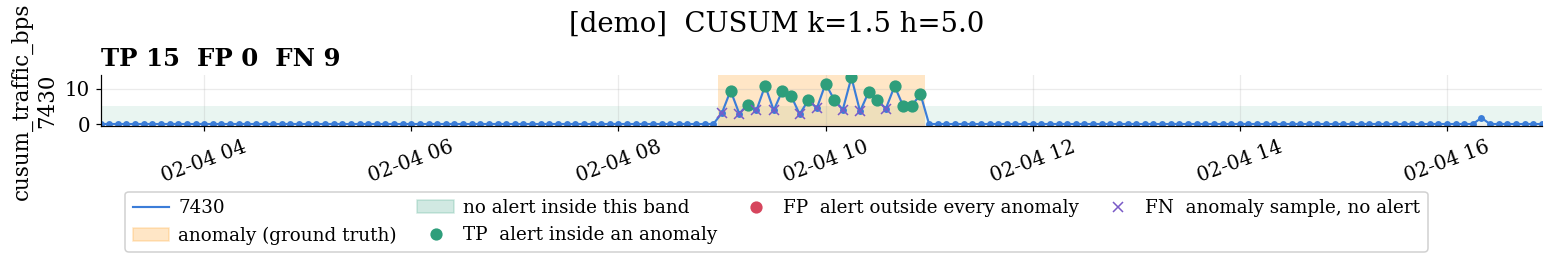

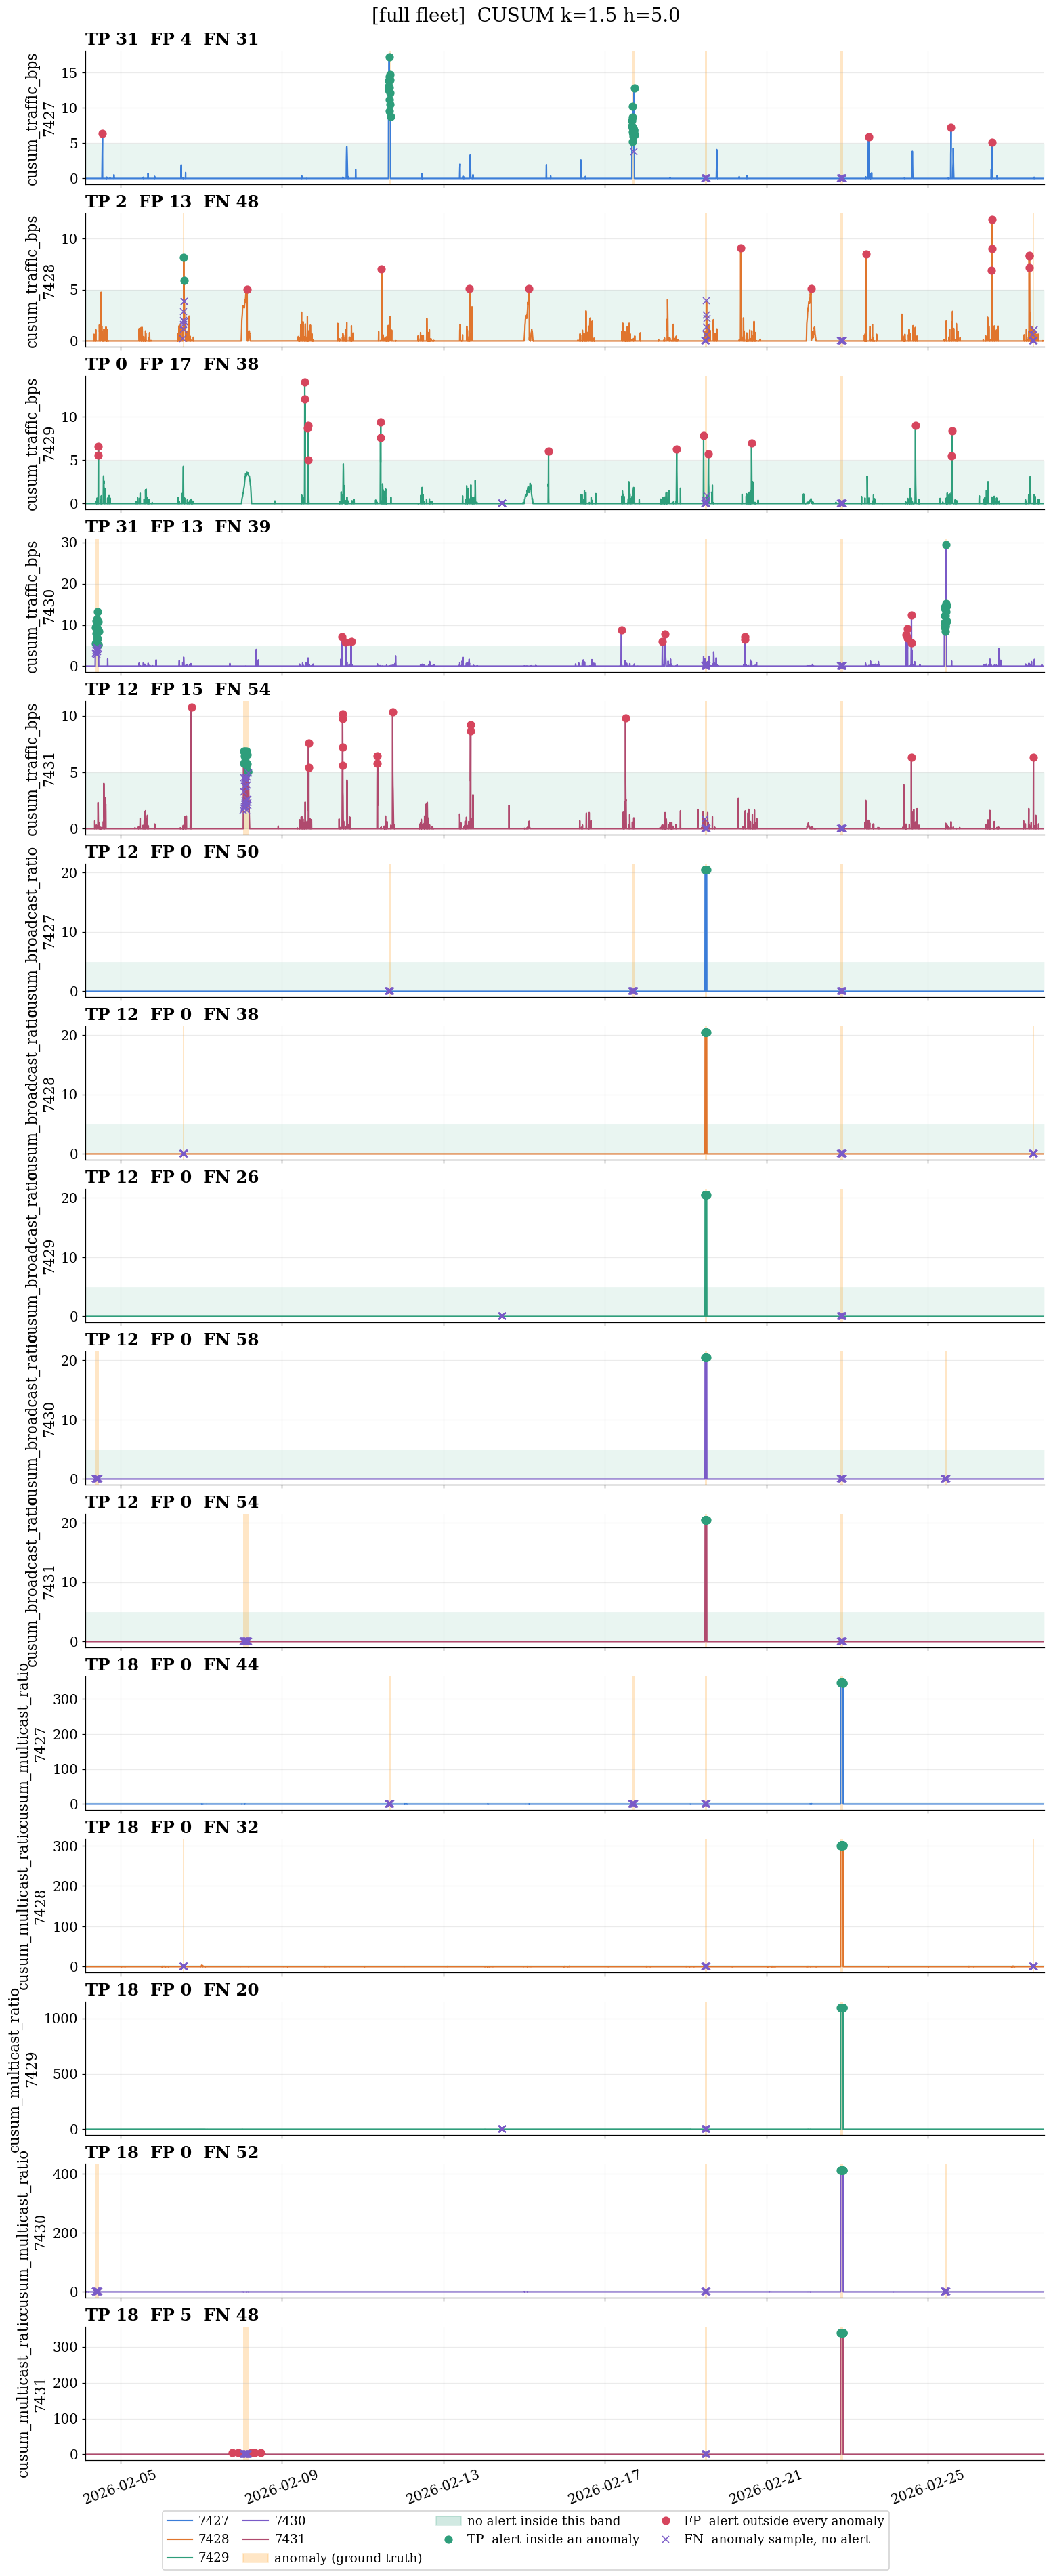

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,CUSUM traffic_bps,160,0.475,6/18,2.5,2.80
1,CUSUM broadcast_ratio,60,1.000,5/18,0.0,0.00
2,CUSUM multicast_ratio,95,0.947,5/18,0.0,0.17


In [7]:
def cusum(data, columns, ports, k=1.5, h=5.0, train_frac=TRAIN_FRAC):
    """Write one whole-history CUSUM column per signal's residual, computed within each port."""
    for col in columns:
        out = f"cusum_{col}"
        data[out] = np.nan
        for pid in ports:
            m = data["port_id"] == pid
            resid = data.loc[m, f"resid_{col}"].to_numpy(dtype=float)
            train = resid[:int(train_frac * len(resid))]
            z = (resid - train.mean()) / train.std()
            data.loc[m, out] = cusum_score(z, k=k, h=h)[0]


cusum(data=df, columns=COLUMNS, ports=PORTS, k=1.5, h=5.0)
cusum_cols = [f"cusum_{col}" for col in COLUMNS]
cusum_alerts = {c: df[c] > 5.0 for c in cusum_cols}
cusum_bands = {c: (0.0, 5.0) for c in cusum_cols}
plot_signals(half=HALF, data=df, columns=[f"cusum_{CUSUM_EWMA_DEMO['column']}"],
            ports=[CUSUM_EWMA_DEMO["port"]], events=[CUSUM_EWMA_DEMO["event"]],
            alerts=cusum_alerts, bands=cusum_bands,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title="[demo]  CUSUM k=1.5 h=5.0")
plot_signals(half=HALF, data=df, columns=cusum_cols, ports=PORTS, events=ANOMALY_TYPES,
            alerts=cusum_alerts, bands=cusum_bands,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title="[full fleet]  CUSUM k=1.5 h=5.0")
report(alerts={f"CUSUM {col}": df[f"cusum_{col}"] > 5.0 for col in COLUMNS},
      data=df, ports=PORTS, events="all")

## Step 6 — EWMA, and why a control limit is not optional

CUSUM accumulates; EWMA weights.

$$s_t = \lambda z_t + (1 - \lambda) s_{t-1}$$

- **`lambda` sets the memory,** roughly $(2-\lambda)/\lambda$ samples.
  - Small is a long memory and a smooth statistic; large approaches the raw score.
- **The trap is the scale.**
  - The EWMA of a standardised series has standard deviation $\sqrt{\lambda/(2-\lambda)}$.
  - That is 0.33 at $\lambda = 0.2$ — a third of the size the threshold was written for.
- **Dividing by the control limit puts every `lambda` back on one axis,** where 4 means what it means
  everywhere else.

In [8]:
def ewma_score(z, lam=0.2, L=1.0):
    """Geometrically weighted mean of a standardised series, rescaled onto the sigma axis.

    Dividing by L * sqrt(lam / (2 - lam)) is what lets one threshold serve every lam. Skip it and
    the statistic is a fraction of the raw score, so nothing ever crosses a cutoff of 4.
    """
    z = pd.Series(np.asarray(z, dtype=float)).fillna(0.0)
    s = z.ewm(alpha=lam, adjust=False).mean()
    limit = L * np.sqrt(lam / (2 - lam))
    return s / limit


port = PORTS[1]
g = series_of(port=port, col=COLUMNS[0], data=df)
resid = g["resid"].to_numpy()                    # Lab 01 Step 15, read rather than recomputed
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()

rows_e = []
for lam in (0.05, 0.1, 0.2, 0.4, 0.8):
    raw = pd.Series(z).ewm(alpha=lam, adjust=False).mean()
    scaled = ewma_score(z=z, lam=lam, L=1.0)
    limit = np.sqrt(lam / (2 - lam))
    rows_e.append({"lam": lam, "memory_samples": round((2 - lam) / lam, 1),
                   "control_limit": round(float(limit), 4),
                   "implied_threshold_if_unscaled": round(4.0 / float(limit), 2),
                   "raw alerts > 4": int((raw.abs() > 4).sum()),
                   "rescaled alerts > 4": int((scaled.abs() > 4).sum())})
pd.DataFrame(rows_e)


,lam,memory_samples,control_limit,implied_threshold_if_unscaled,raw alerts > 4,rescaled alerts > 4
0,0.05,39.0,0.1601,24.98,0,2166
1,0.10,19.0,0.2294,17.44,0,1580
2,0.20,9.0,0.3333,12.00,3,1043
3,0.40,4.0,0.5000,8.00,14,254
4,0.80,1.5,0.8165,4.90,22,29


**`implied_threshold_if_unscaled` is the column to read.** An unscaled EWMA compared to 4 is
really z compared to 4 ÷ the control limit — **12.0** at λ=0.2, **17.4** at 0.1, **25.0** at
0.05. Nothing errors, nothing warns.

- **Three to six times stricter than the config claims** — the alert-count columns show the cost.
- **Unscaled, sensitivity couples to memory length:** tuning λ for smoothness silently retunes
  the threshold too. The rescale exists to break that coupling.
- **This residual still fires anyway** — |z| clears 12 during the anomaly. A quieter signal would
  go silent instead: survivable here, fatal elsewhere. Worth a cell, not a comment.

#### Your call — `lam`

**The decision:** how much memory the statistic carries. Small `lam` is a long memory and a
smooth statistic; large `lam` approaches the raw score with almost none.
`implied_threshold_if_unscaled` above already showed what happens when this choice and the alert
cutoff drift apart unnoticed.

- **Memory and delay are the same knob.** A long memory averages out routine noise, and it also
  averages out the anomaly — EWMA's own late peak and slow decay above are the cost of whatever
  `lam` bought.
- **The control-limit rescale does not remove this tradeoff, only the accounting error.** A
  rescaled EWMA at any `lam` still trades responsiveness for smoothness; rescaling just
  guarantees the number you compare against 4 means the same thing at every setting.
- **Short memory degenerates toward the raw z-score,** which needs no EWMA at all. The useful
  range sits well below `lam = 1`, and how far below is a property of how noisy your own signal
  is.

**Do it now.** Set `lam = 0.05`, re-run this step, then `lam = 0.8`. Watch alert count *and*
delay to first alert together, not either alone — and check whether
`implied_threshold_if_unscaled` would have told you which end was already miscalibrated before
you looked at a single alert.

### EWMA, every port and column

Same fleet-wide rule as CUSUM's: one `lam`, one rescaled cutoff, reset independently per port.

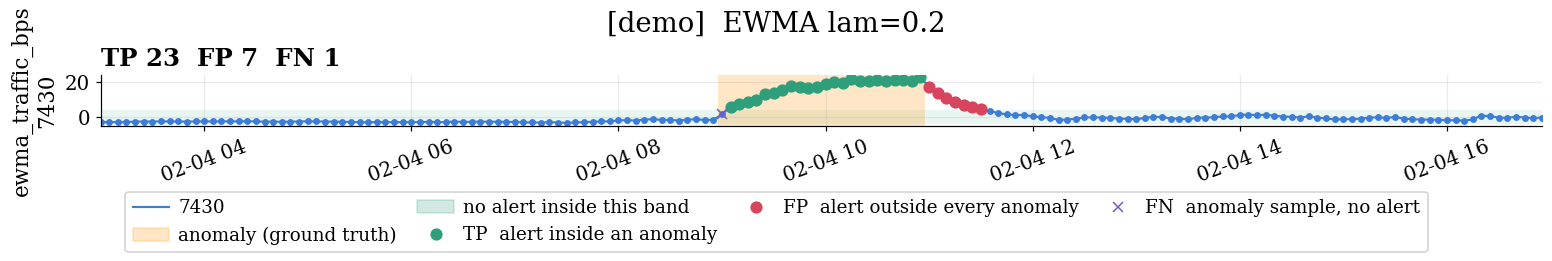

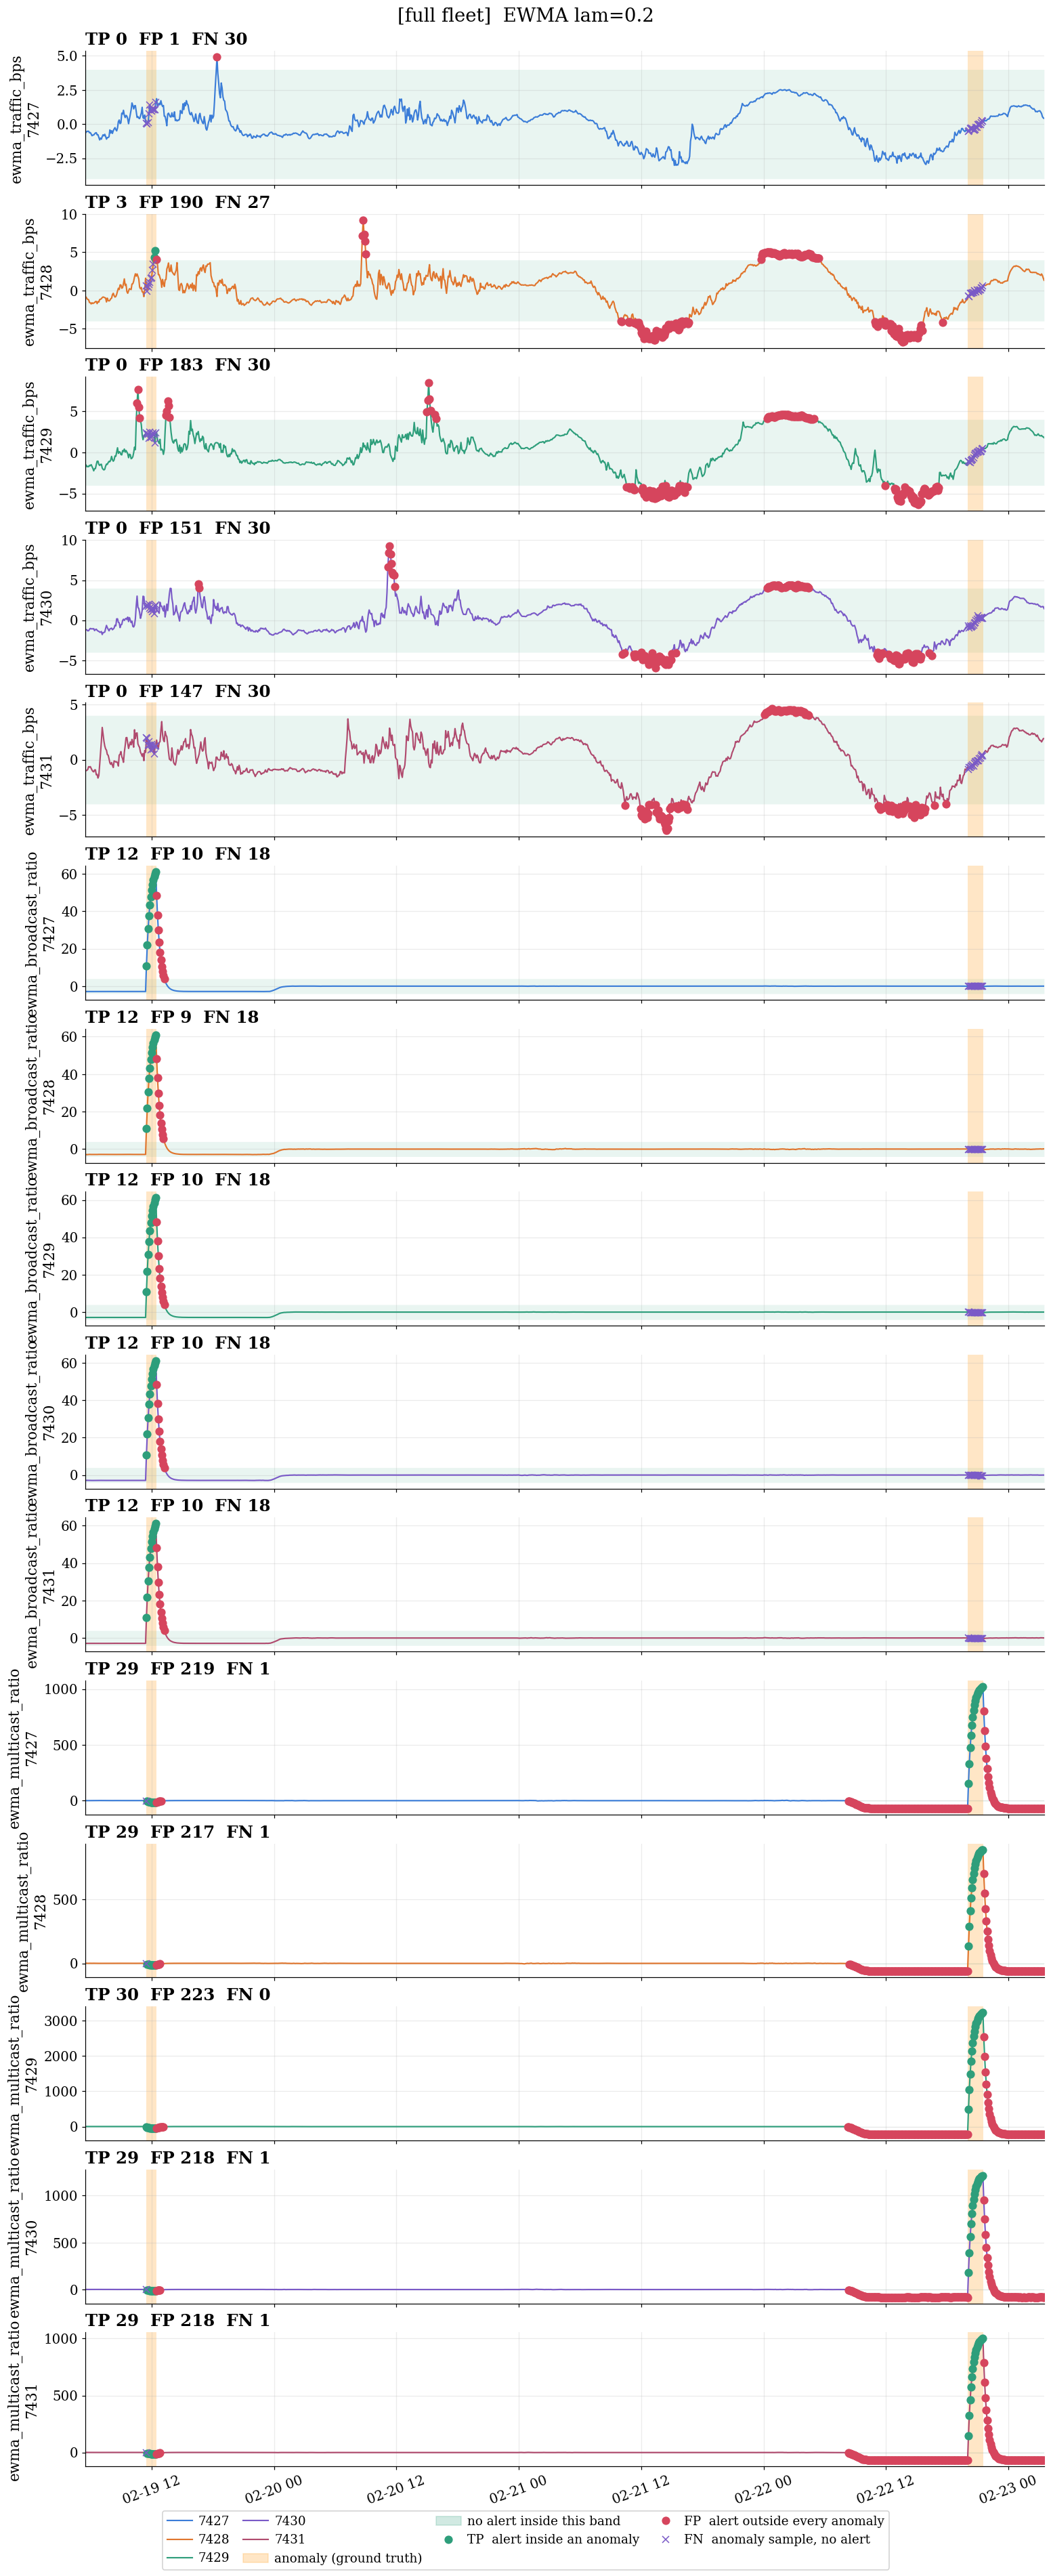

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,EWMA traffic_bps,3685,0.033,8/18,0.0,118.85
1,EWMA broadcast_ratio,110,0.555,6/18,0.0,1.63
2,EWMA multicast_ratio,2024,0.126,16/18,0.0,58.97


In [9]:
def ewma(data, columns, ports, lam=0.2, L=1.0, train_frac=TRAIN_FRAC):
    """Write one whole-history EWMA column per signal's residual, computed within each port."""
    for col in columns:
        out = f"ewma_{col}"
        data[out] = np.nan
        for pid in ports:
            m = data["port_id"] == pid
            resid = data.loc[m, f"resid_{col}"].to_numpy(dtype=float)
            train = resid[:int(train_frac * len(resid))]
            z = (resid - train.mean()) / train.std()
            data.loc[m, out] = ewma_score(z, lam=lam, L=L).to_numpy()


ewma(data=df, columns=COLUMNS, ports=PORTS, lam=0.2, L=1.0)
ewma_cols = [f"ewma_{col}" for col in COLUMNS]
ewma_alerts = {c: df[c].abs() > 4 for c in ewma_cols}
ewma_bands = {c: (-4.0, 4.0) for c in ewma_cols}
plot_signals(half=HALF, data=df, columns=[f"ewma_{CUSUM_EWMA_DEMO['column']}"],
            ports=[CUSUM_EWMA_DEMO["port"]], events=[CUSUM_EWMA_DEMO["event"]],
            alerts=ewma_alerts, bands=ewma_bands,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title="[demo]  EWMA lam=0.2")
plot_signals(half=HALF, data=df, columns=ewma_cols, ports=PORTS, events=ZOOM_EVENTS,
            alerts=ewma_alerts, bands=ewma_bands,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title="[full fleet]  EWMA lam=0.2")
report(alerts={f"EWMA {col}": df[f"ewma_{col}"].abs() > 4 for col in COLUMNS},
      data=df, ports=PORTS, events="all")

## Step 7 — Multi-Variate detectors

- **Two single-signal statistics down, one multi-signal family to go.** CUSUM and EWMA
  each watch one number; these three watch a whole feature vector at once.
- **Lab 01 shipped three ways of presenting one column, none of them a detector:**
  - **raw** — the scaled value on its own
  - **deseasonalised** — the residual after the day's expected shape is subtracted
  - **window`N_INPUT`** — a sliding window of the last `N_INPUT` values
- **Same three scikit-learn detectors on all three, one table** — 5a to 5c below go from the
  weakest showing on this port to the strongest, measured, before the combined sweep.
- **Where the scaling comes from matters.** The first two are shipped columns, scaled from the
  spec, nothing refitted. The window matrix isn't shipped — 36 overlapping copies of a column
  this lab already has — so its scale rebuilds here from training rows alone.
  - **A shipped column carries its scaler; a view rebuilds one from training rows.** Either way,
    no test sample sets a scale.

In [10]:
def fit_models(train, full, seed=0):
    """Fit three off-the-shelf detectors on `train`, score `full`. Higher score = more anomalous.

    Each library method returns higher-is-more-normal, so every score is negated. OneClassSVM is
    fitted on every tenth training row, which keeps a quadratic-time solver inside a teaching
    notebook's patience.
    """
    return {
        "IsolationForest": -IsolationForest(n_estimators=100, random_state=seed)
                            .fit(train).score_samples(full),
        "OneClassSVM": -OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
                        .fit(train[::10]).score_samples(full),
        "LOF": -LocalOutlierFactor(n_neighbors=20, novelty=True).fit(train).score_samples(full),
    }


def framings(g, port, col, n_input, train_frac, scalers):
    """{name: (X, split, pad)} for the three representations a detector gets compared on.

    `raw` and `deseasonalised` each read one scaler out of `scalers[f"{port}|{col}"]`, fitted on
    the training half elsewhere and never refitted here. `window{n_input}` scales each sliding
    window against its own training slice instead, since one scalar mean/scale cannot flatten a
    window's internal shape.
    """
    k = int(train_frac * len(g))

    W = sliding_windows(g["value"], n_input=n_input)
    kw = int(train_frac * len(W))
    scale = W[:kw].std(axis=0)
    Xw = (W - W[:kw].mean(axis=0)) / np.where(scale == 0, 1.0, scale)

    def scaled(values, key):
        sc = scalers[key]
        return apply_scaler(values, sc["mean"], sc["scale"])

    return {
        "raw": (scaled(g["value"], f"{port}|{col}").reshape(-1, 1), k, 0),
        "deseasonalised": (scaled(g["resid"], f"{port}|resid_{col}").reshape(-1, 1), k, 0),
        f"window{n_input}": (Xw, kw, n_input - 1),
    }

### 5a — LOF (Local Outlier Factor)

$$\mathrm{LOF}_k(x) = \frac{1}{k}\sum_{o \in N_k(x)} \frac{\mathrm{lrd}_k(o)}{\mathrm{lrd}_k(x)}$$

- **Local reachability density (`lrd`)** is roughly one over the average distance to a point's
  `k` nearest neighbours — how crowded its own neighbourhood is.
- **LOF compares that density to the neighbours' own density, not to the whole dataset's.** A
  point in as dense a neighbourhood as its neighbours scores near 1; one sitting in a sparser
  pocket than everything around it scores well above 1.
- **That locality is the point.** A global density check averages away a pocket that's merely
  sparse *relative to its own region* — the contextual anomalies this lab keeps returning to.
- **`n_neighbors=20`** sets `k`: too few and one stray point defines "normal"; too many and a
  genuinely local pocket gets compared against neighbours from outside it.

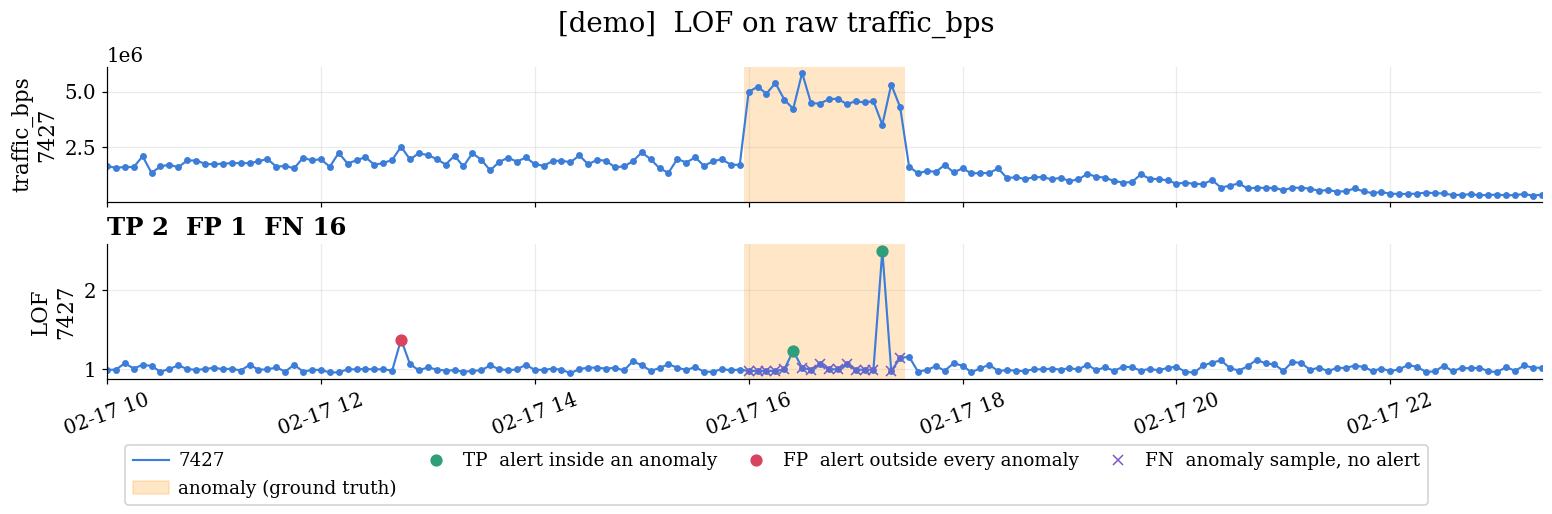

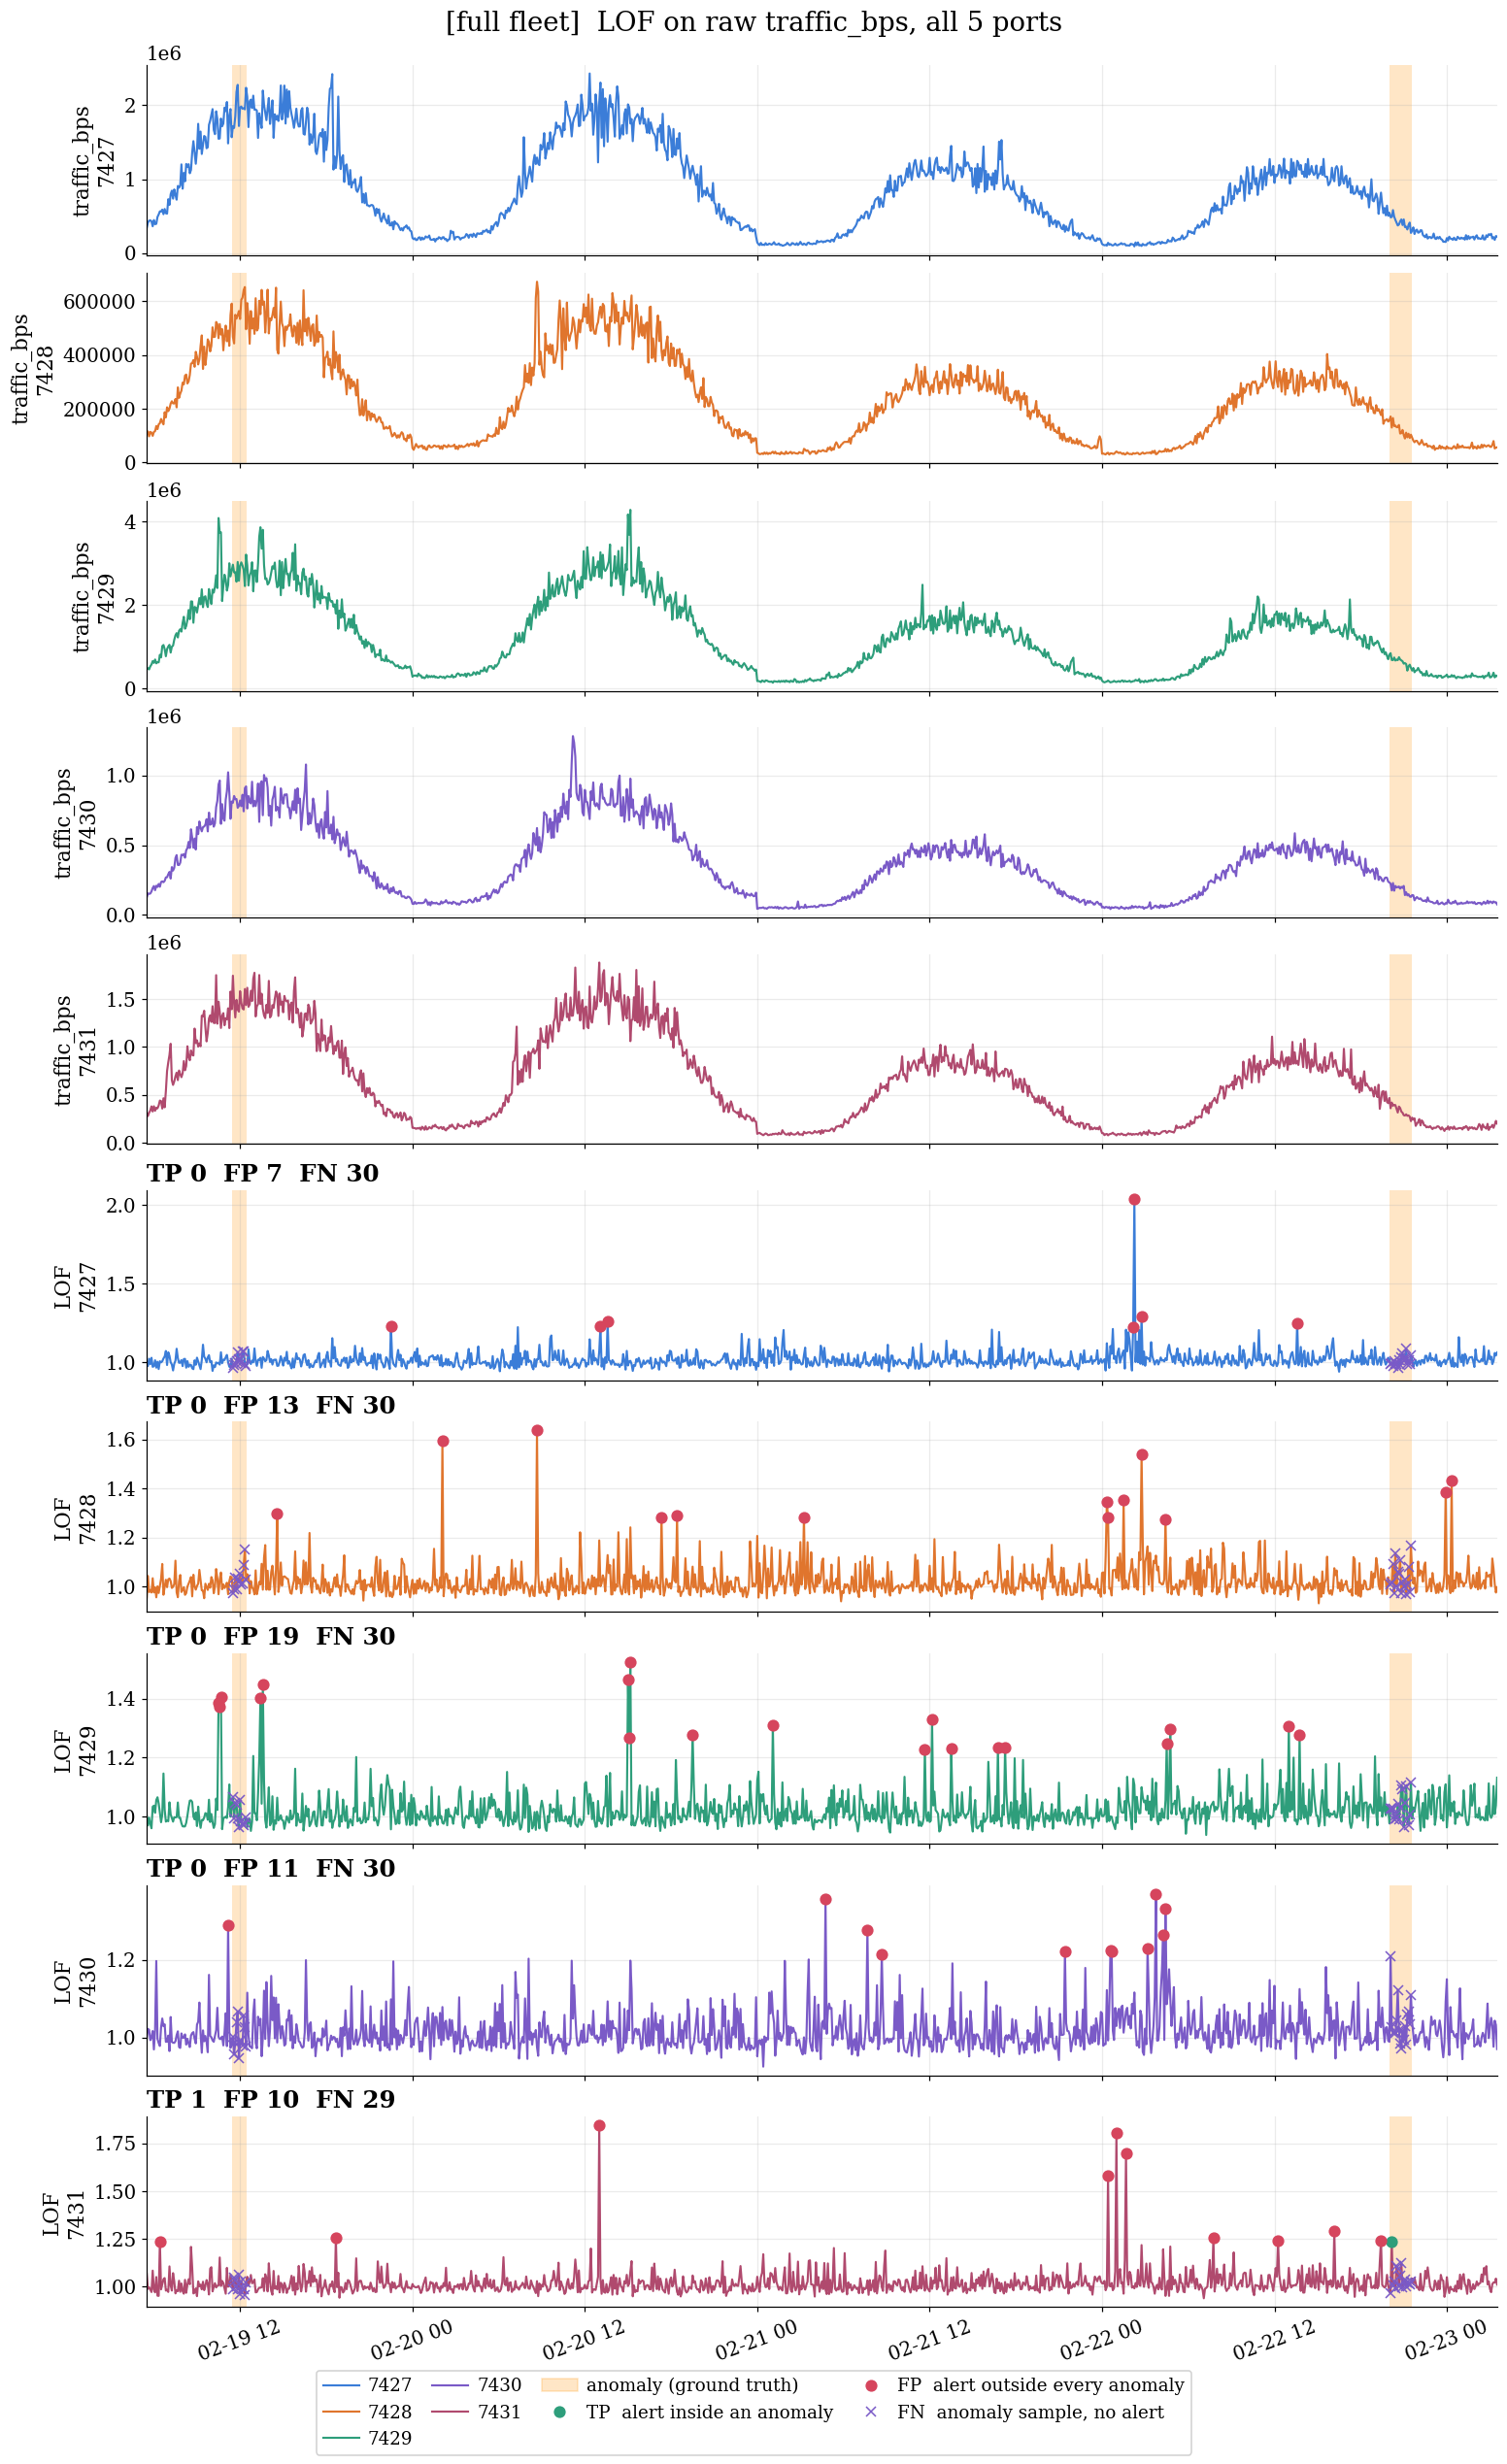

In [11]:
demo_col = COLUMNS[0]
X_by_port = {}
for p in PORTS:
    gp = series_of(port=p, col=demo_col, data=df)
    X_by_port[p] = framings(gp, port=p, col=demo_col, n_input=N_INPUT,
                            train_frac=TRAIN_FRAC, scalers=SCALERS)["raw"][:2]


def fit_every_port(model_fn):
    """model_fn(train) -> a fitted model with .score_samples. One df-aligned score per port."""
    score = pd.Series(np.nan, index=df.index)
    for p in PORTS:
        X, k = X_by_port[p]
        score.loc[df.index[df["port_id"] == p]] = -model_fn(X[:k]).score_samples(X)
    return score


score_lof = fit_every_port(lambda train: LocalOutlierFactor(n_neighbors=20, novelty=True).fit(train))
df["LOF"] = score_lof
thr_lof = score_lof.groupby(df["port_id"]).transform(lambda s: s.quantile(BUDGET))
lof_alerts = {"LOF": (df["LOF"] > thr_lof).fillna(False)}
plot_signals(half=HALF, data=df, columns=[demo_col, "LOF"],
            ports=[MULTIVARIATE_DEMO["port"]], events=[MULTIVARIATE_DEMO["event"]],
            alerts=lof_alerts, outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title=f"[demo]  LOF on raw {demo_col}")
plot_signals(half=HALF, data=df, columns=[demo_col, "LOF"], ports=PORTS,
            events=ZOOM_EVENTS, alerts=lof_alerts,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title=f"[full fleet]  LOF on raw {demo_col}, all 5 ports")

### 5b — OneClassSVM

- **Fits a boundary, not a distance.** A kernel maps the training points into a
  higher-dimensional space where a hyperplane can separate the dense region from everything
  else; mapped back, that hyperplane becomes a boundary around normal shapes the raw space
  wouldn't show.
- **`nu` sets the boundary's tightness two ways at once:** an upper bound on the training
  fraction allowed outside it, and a lower bound on the fraction that ends up defining it.
  `nu=0.01` asks for a boundary that excludes at most 1% of training as outliers.
- **`gamma="scale"`** sets the kernel's reach from the data's own variance, so a tight or
  spread-out signal doesn't need `gamma` retuned by hand.
- **Every training row costs against every other** — the solver is quadratic in sample count,
  why the fit below only sees every tenth training row.

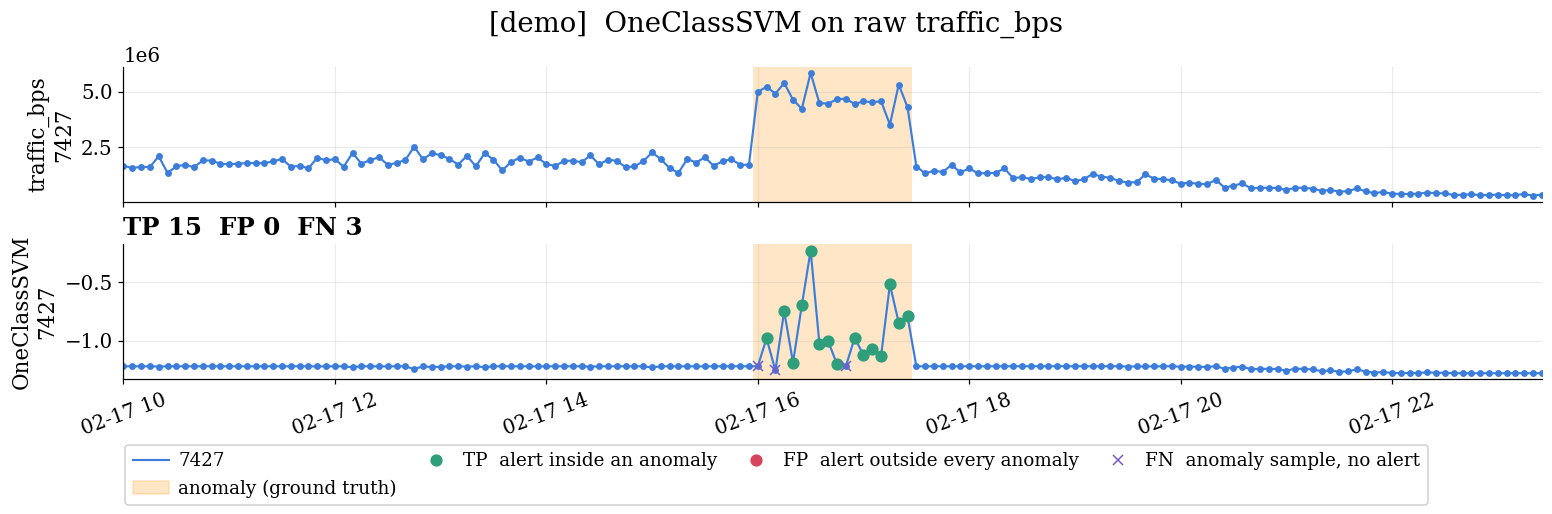

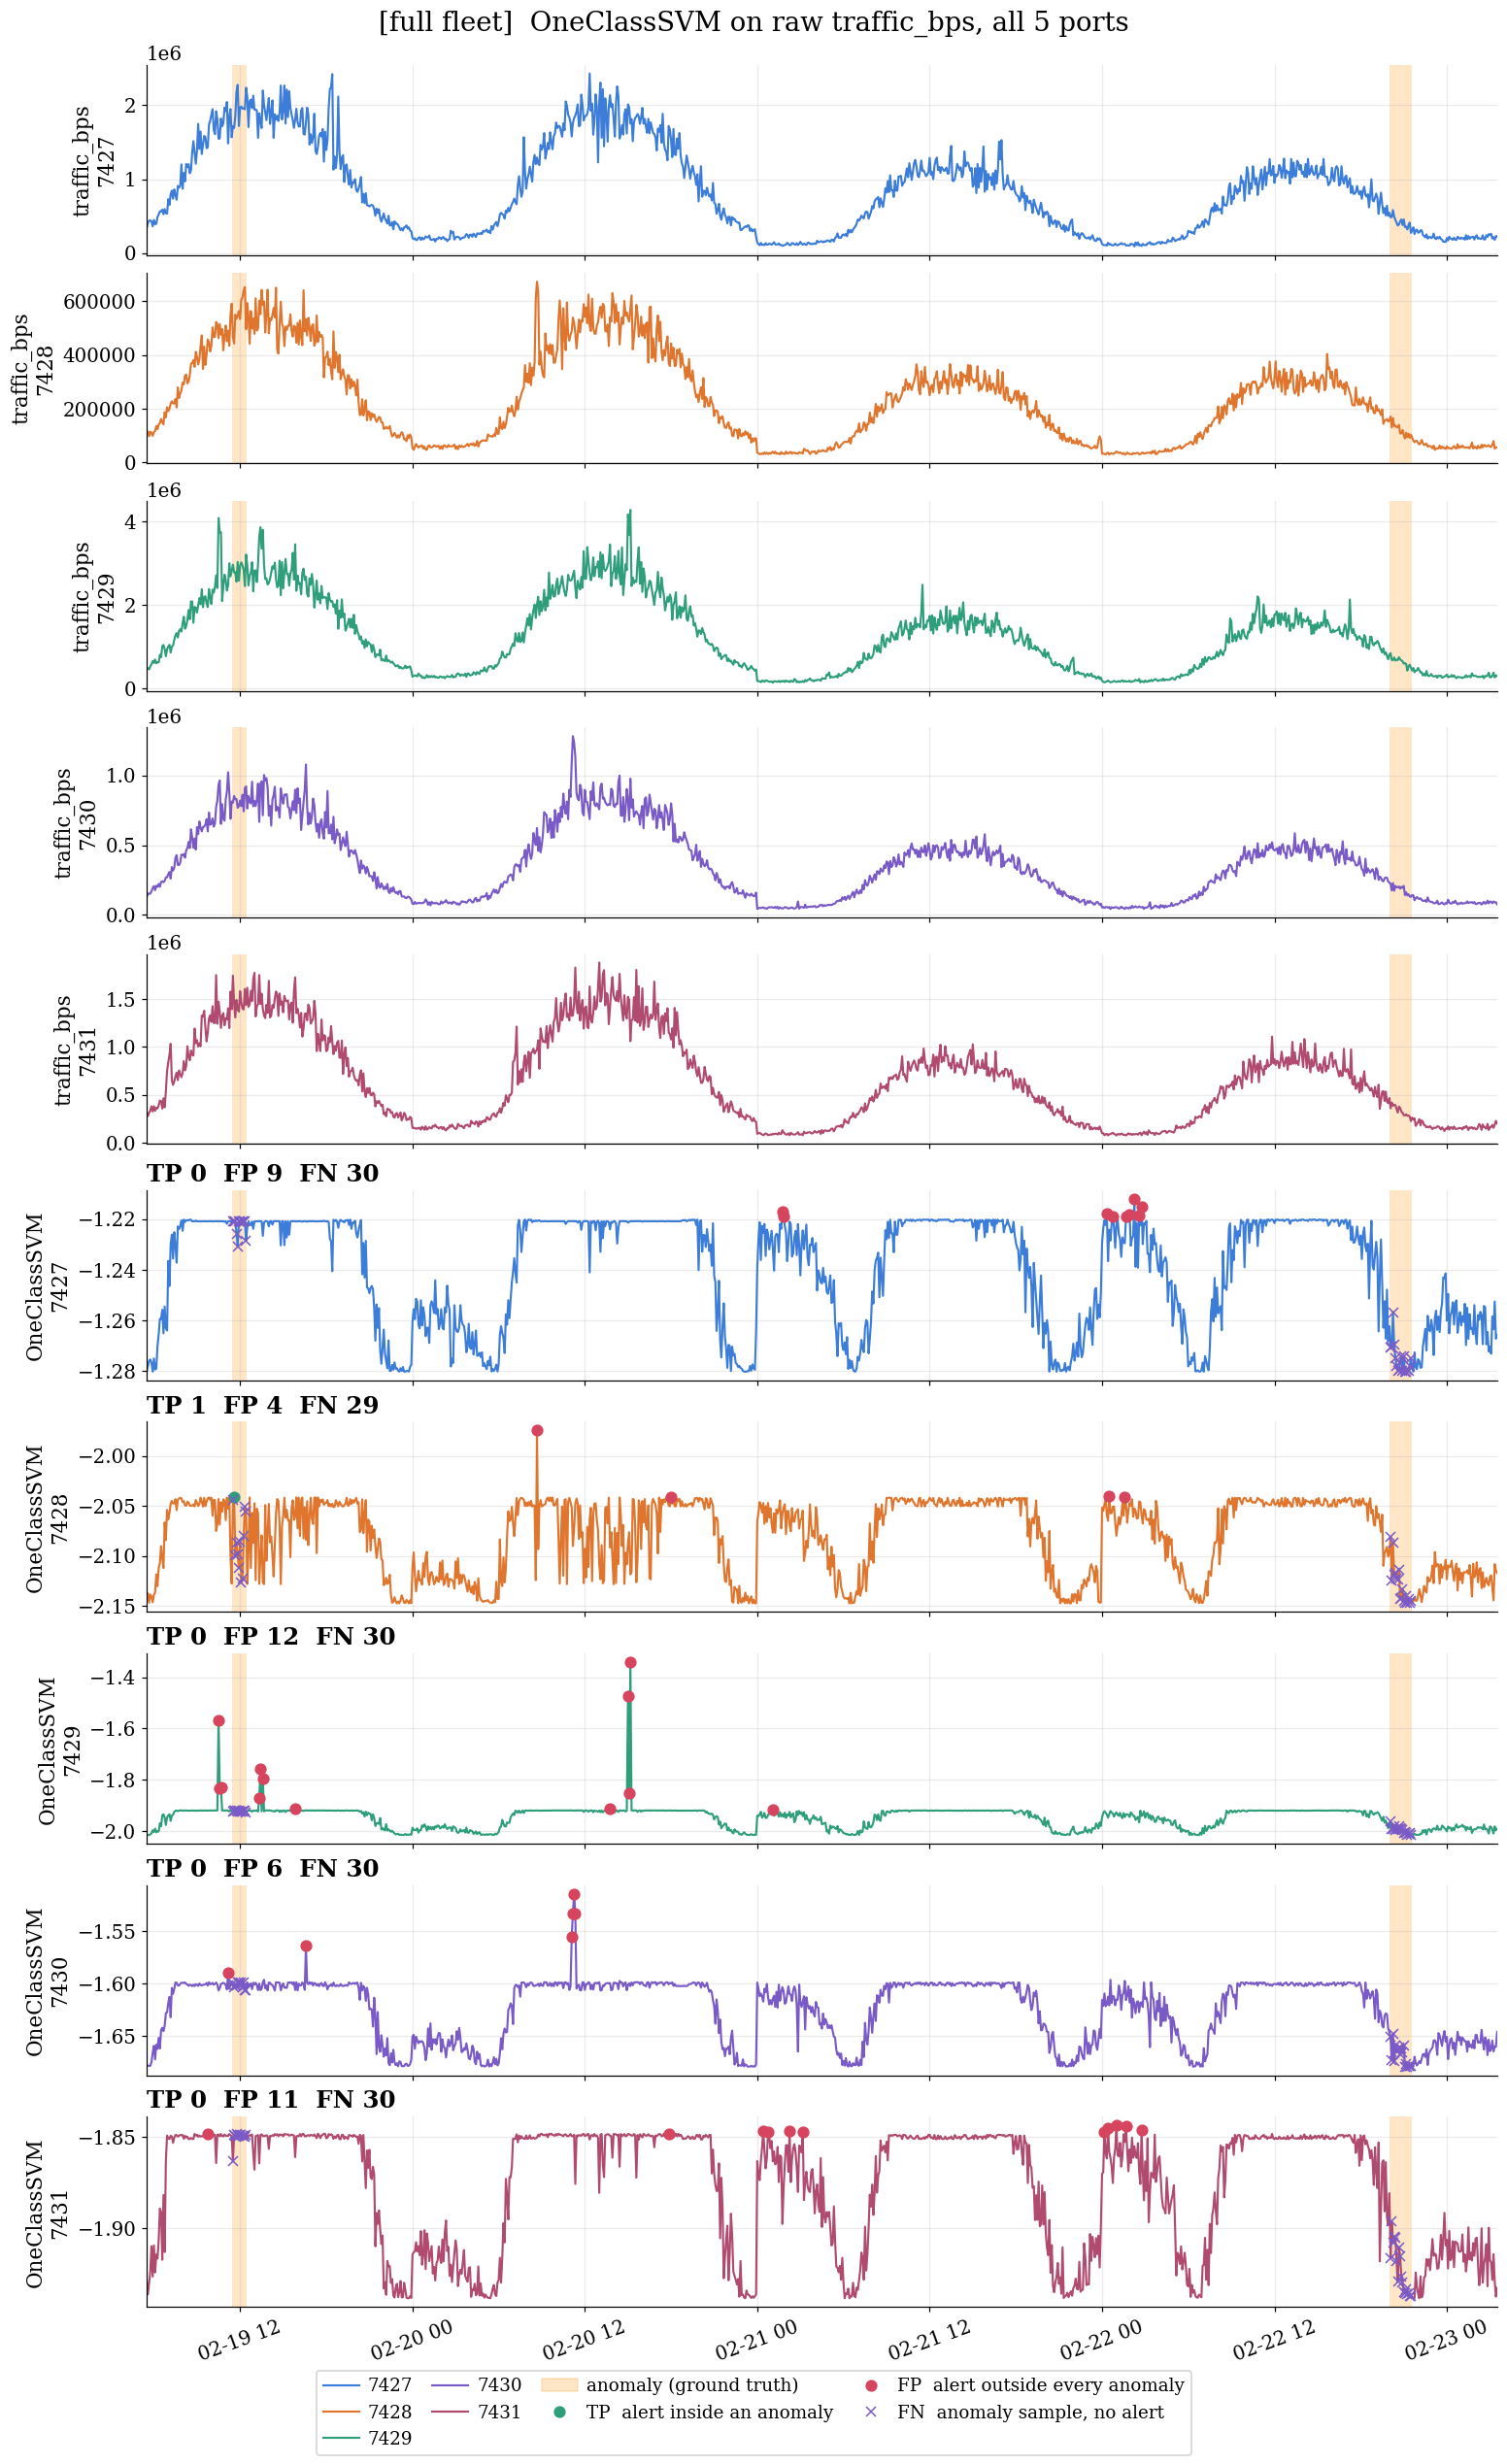

In [12]:
score_svm = fit_every_port(lambda train: OneClassSVM(kernel="rbf", nu=0.01,
                                                     gamma="scale").fit(train[::10]))
df["OneClassSVM"] = score_svm
thr_svm = score_svm.groupby(df["port_id"]).transform(lambda s: s.quantile(BUDGET))
svm_alerts = {"OneClassSVM": (df["OneClassSVM"] > thr_svm).fillna(False)}
plot_signals(half=HALF, data=df, columns=[demo_col, "OneClassSVM"],
            ports=[MULTIVARIATE_DEMO["port"]], events=[MULTIVARIATE_DEMO["event"]],
            alerts=svm_alerts, outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title=f"[demo]  OneClassSVM on raw {demo_col}")
plot_signals(half=HALF, data=df, columns=[demo_col, "OneClassSVM"], ports=PORTS,
            events=ZOOM_EVENTS, alerts=svm_alerts,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title=f"[full fleet]  OneClassSVM on raw {demo_col}, all 5 ports")

### 5c — IsolationForest

$$\text{score}(x) = 2^{-E[h(x)]\,/\,c(n)}$$

- **Isolates by random splits.** Each of `n_estimators` trees picks a random feature and a
  random split value, recursively, until every point sits alone in its own leaf.
- **$h(x)$ is how many splits that took.** An outlier is "few and different," so it isolates in
  a short average path length across the forest; a normal point buried in a dense cluster needs
  many splits to peel away from its neighbours.
- **$c(n)$ normalises for tree size** so the score reads on roughly the same scale whatever `n`
  the model was fitted on.
- **No distance, no density — just how hard a point is to fence off alone,** which is cheap even
  where a distance metric stops meaning much.

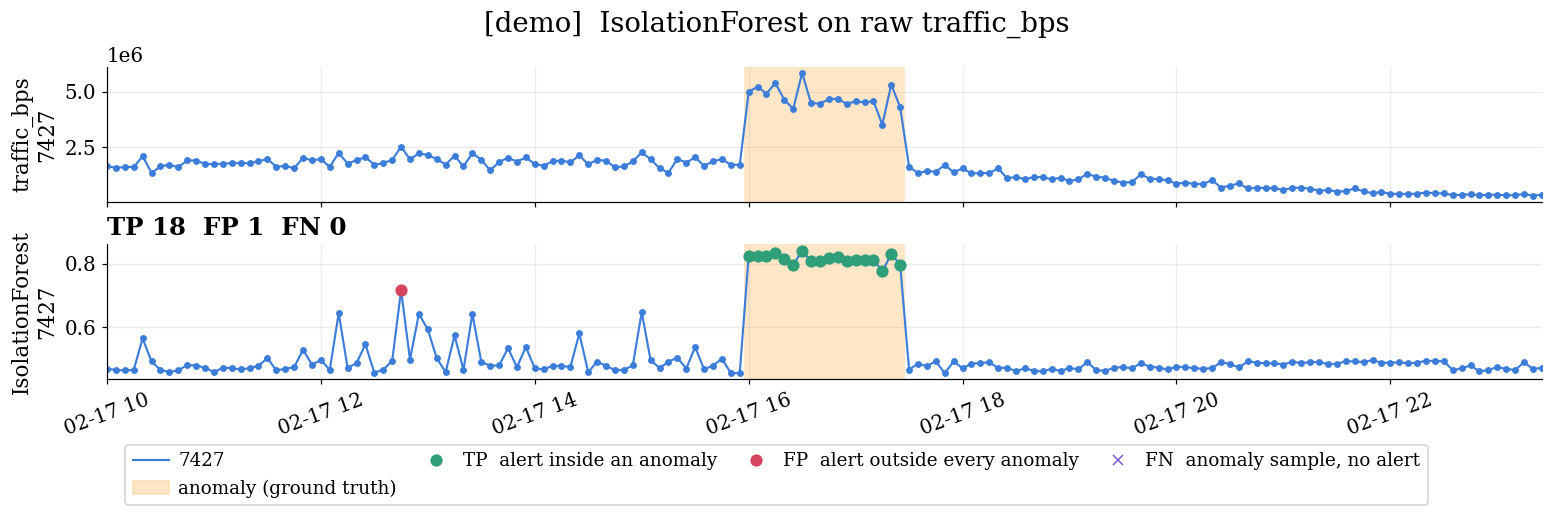

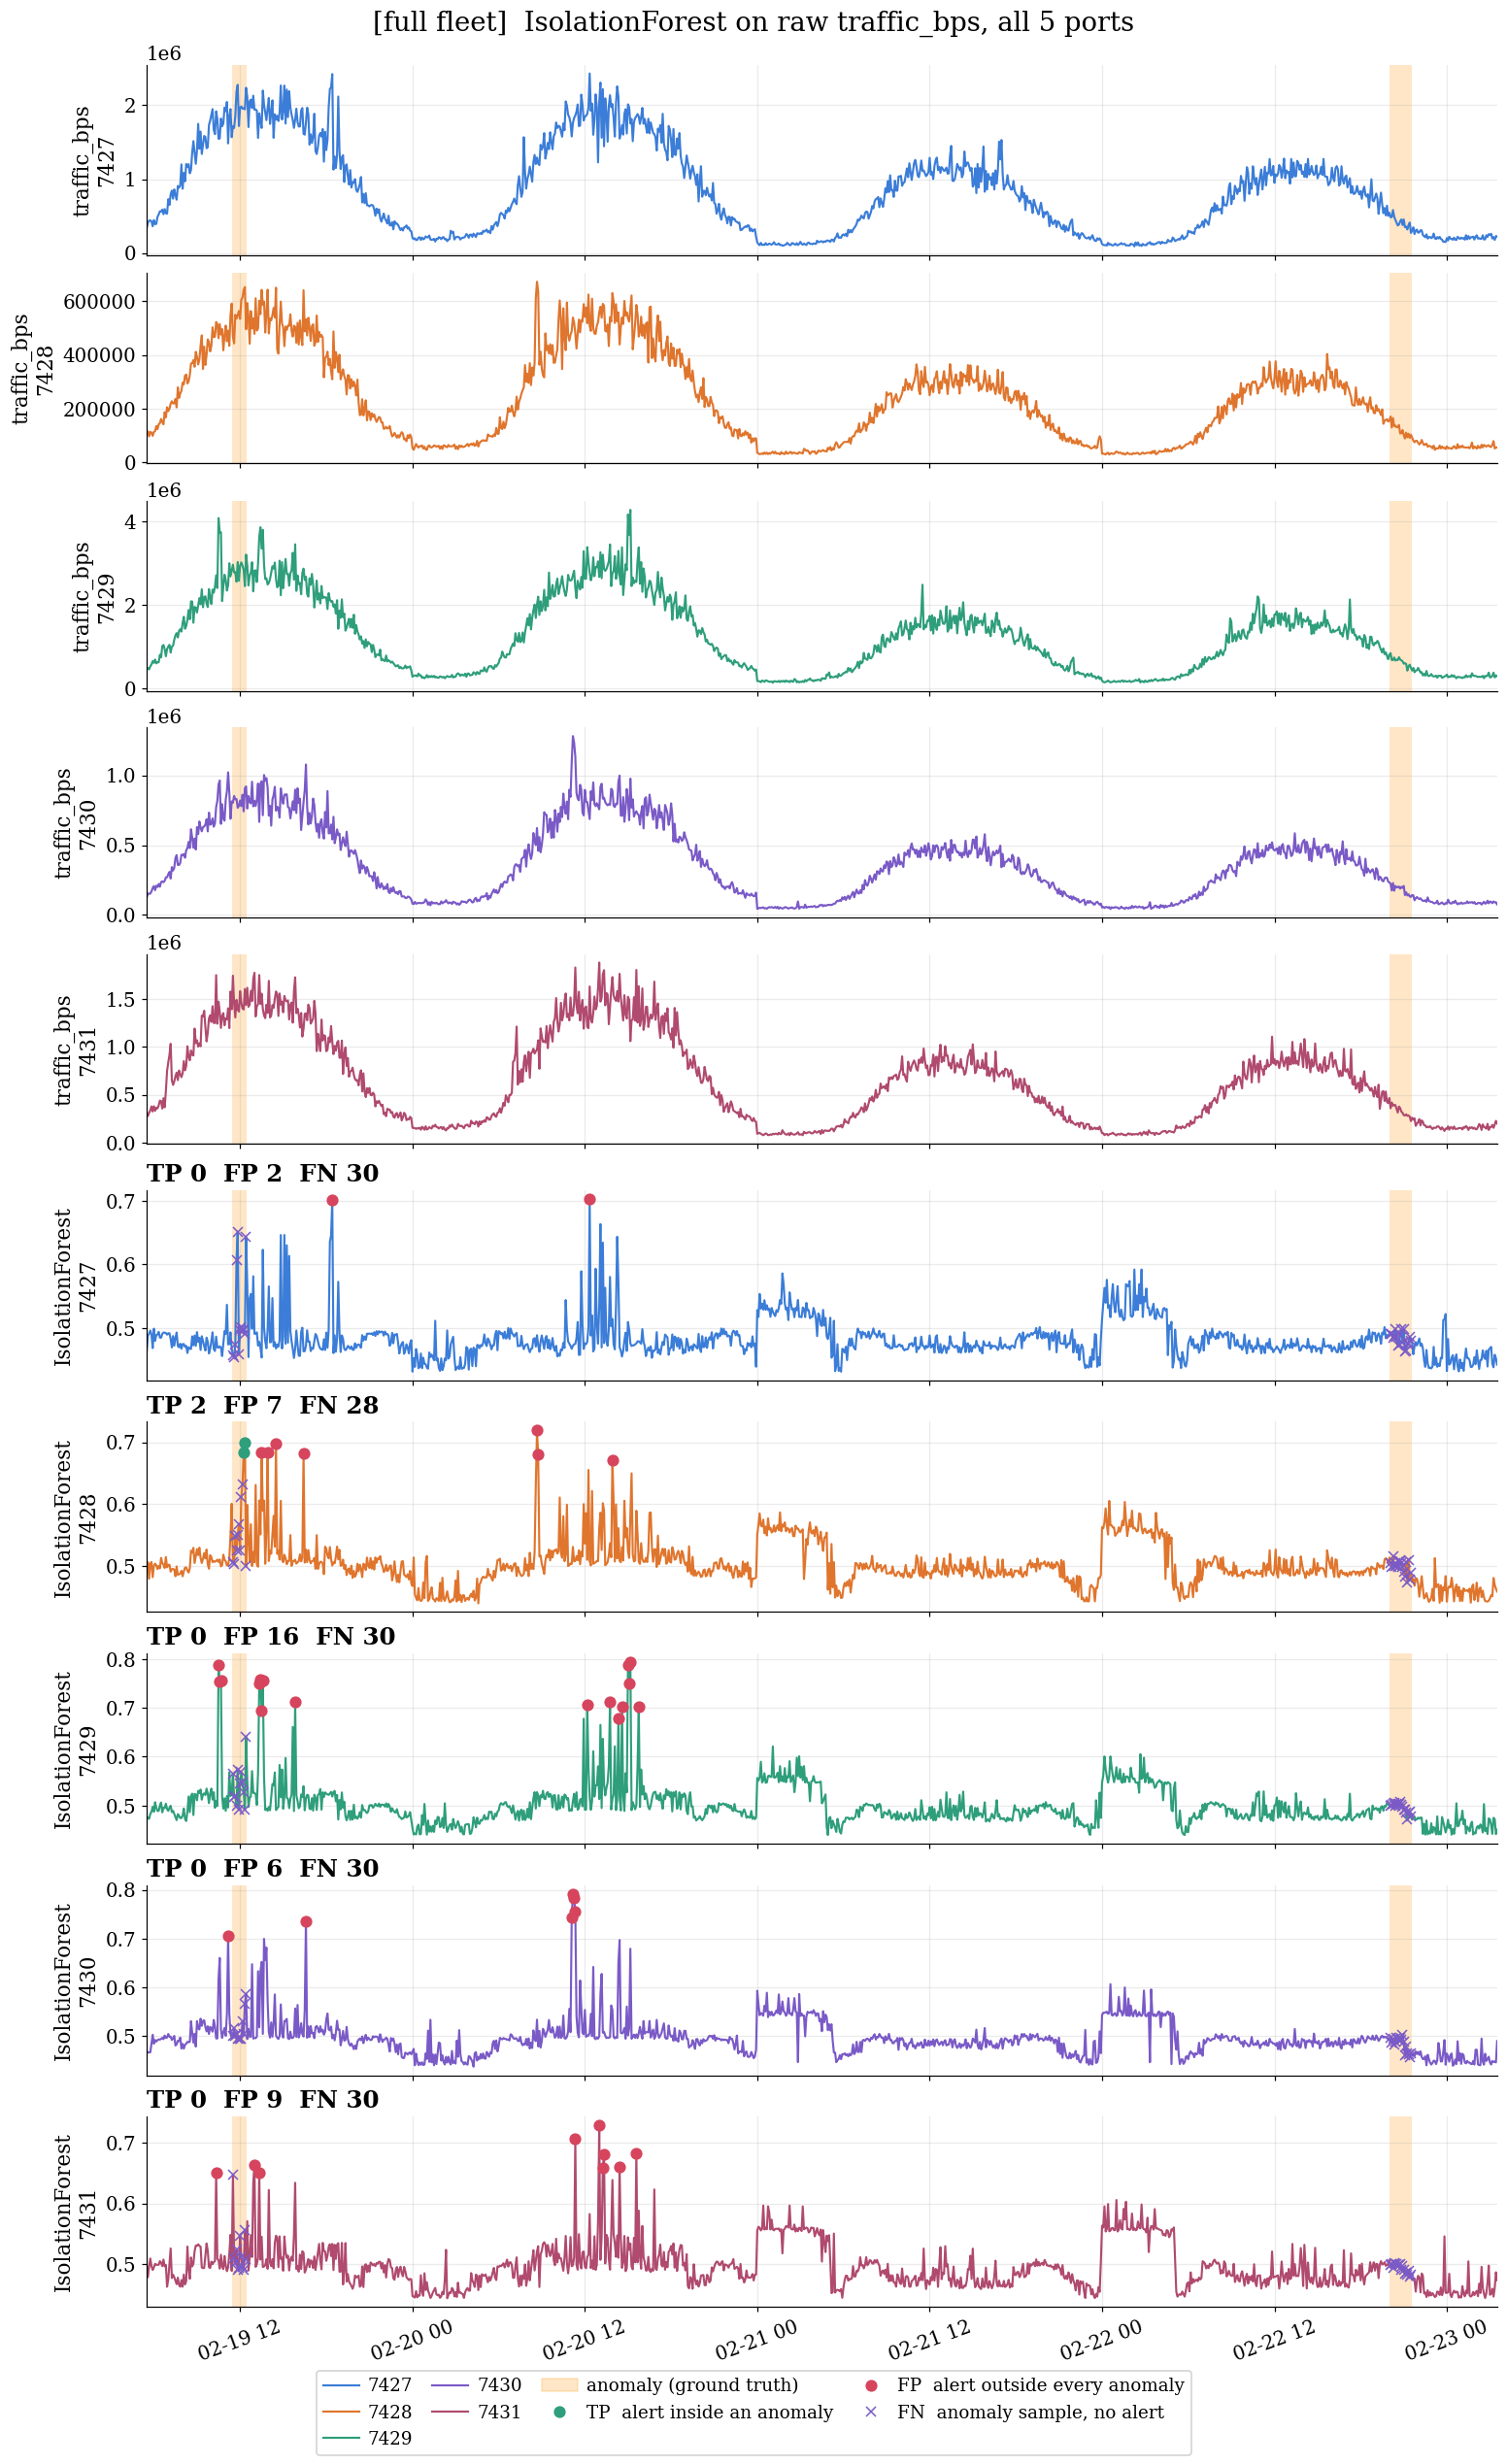

In [13]:
score_if = fit_every_port(lambda train: IsolationForest(n_estimators=100, random_state=0).fit(train))
df["IsolationForest"] = score_if
thr_if = score_if.groupby(df["port_id"]).transform(lambda s: s.quantile(BUDGET))
if_alerts = {"IsolationForest": (df["IsolationForest"] > thr_if).fillna(False)}
plot_signals(half=HALF, data=df, columns=[demo_col, "IsolationForest"],
            ports=[MULTIVARIATE_DEMO["port"]], events=[MULTIVARIATE_DEMO["event"]],
            alerts=if_alerts, outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title=f"[demo]  IsolationForest on raw {demo_col}")
plot_signals(half=HALF, data=df, columns=[demo_col, "IsolationForest"], ports=PORTS,
            events=ZOOM_EVENTS, alerts=if_alerts,
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title=f"[full fleet]  IsolationForest on raw {demo_col}, all 5 ports")

### Comparison, by column and framing

Same budget, every framing, every port and column — whether 5a to 5c's order holds everywhere:

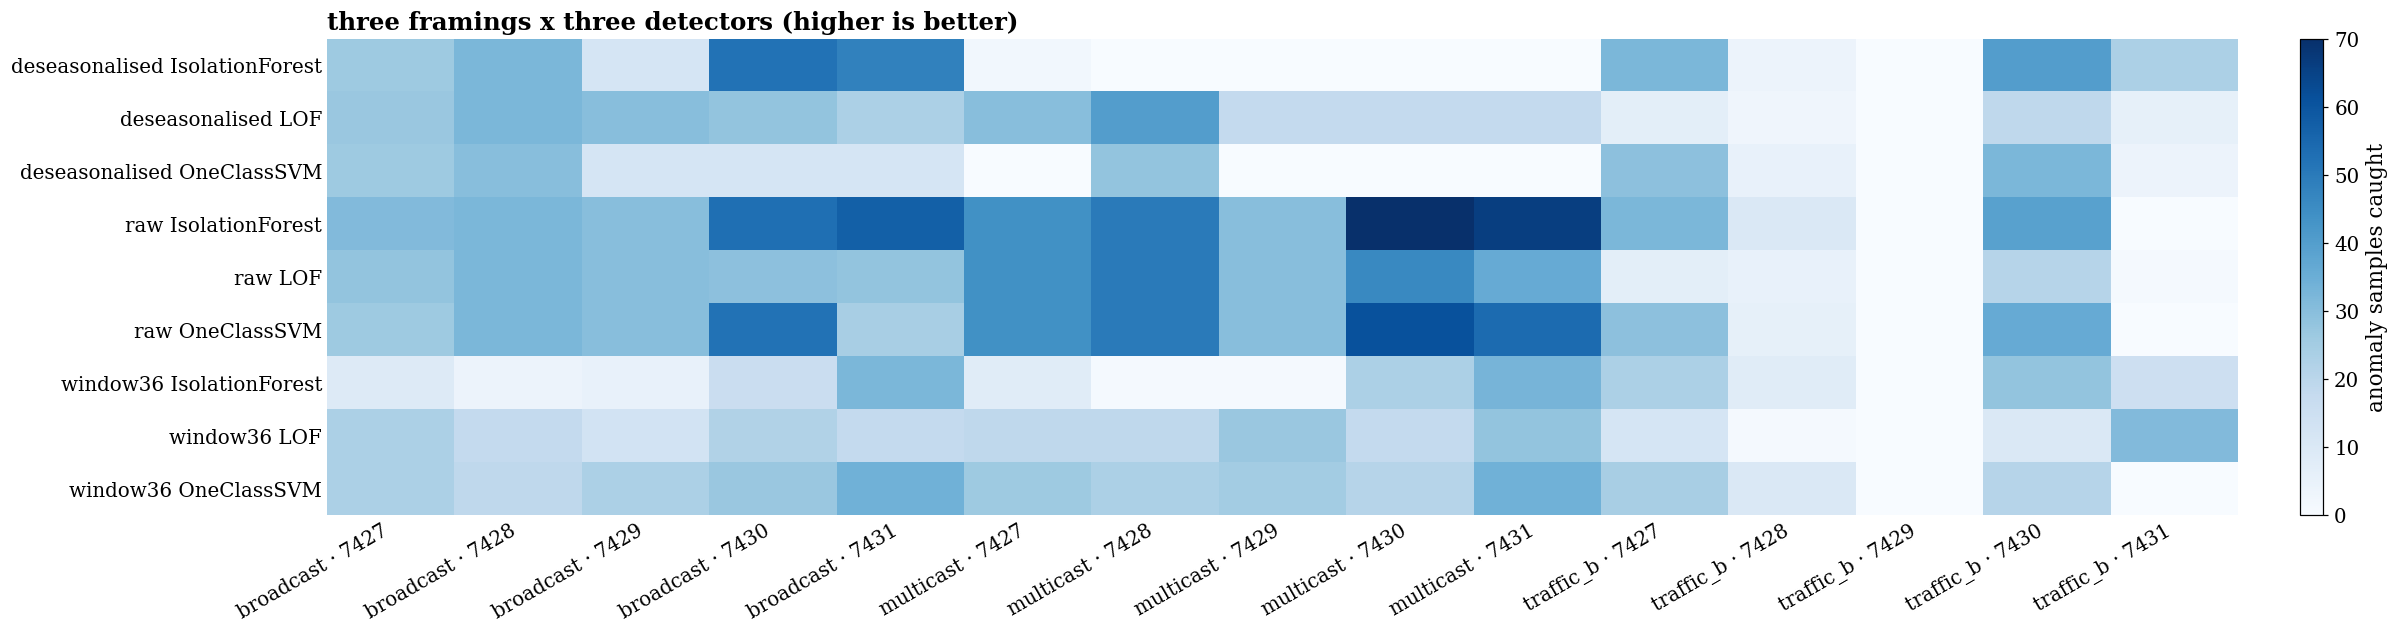

,port,method,alerts,caught,of,precision,column
0,7427,raw IsolationForest,87,32,62,0.368,traffic_bps
1,7427,raw OneClassSVM,87,29,62,0.333,traffic_bps
2,7427,raw LOF,87,7,62,0.080,traffic_bps
3,7427,deseasonalised IsolationForest,85,32,62,0.376,traffic_bps
4,7427,deseasonalised OneClassSVM,87,29,62,0.333,traffic_bps
...,...,...,...,...,...,...,...
130,7431,deseasonalised OneClassSVM,0,0,66,NaN,multicast_ratio
131,7431,deseasonalised LOF,87,18,66,0.207,multicast_ratio
132,7431,window36 IsolationForest,87,33,66,0.379,multicast_ratio
133,7431,window36 OneClassSVM,87,34,66,0.391,multicast_ratio


In [14]:
rows, scores = [], {}
for port, column in [(p, c) for c in COLUMNS for p in PORTS]:
    g = series_of(port=port, col=column, data=df)
    for name, (X, k, pad) in framings(g, port=port, col=column, n_input=N_INPUT,
                                      train_frac=TRAIN_FRAC, scalers=SCALERS).items():
        fitted = fit_models(X[:k], X)
        # a window's score belongs to the sample it ends on, so pad the leading samples
        fitted = {m: np.concatenate([np.full(pad, np.nan), s]) for m, s in fitted.items()}
        scores[port, column, name] = fitted
        for model, s in fitted.items():
            r = evaluate(name=f"{name} {model}", port=port, score=s,
                         target=g["target"], budget=BUDGET)
            rows.append({**r, "column": column})

framing_table = pd.DataFrame(rows)
grid = framing_table.pivot_table(index="method", columns=["column", "port"], values="caught")
grid.columns = [f"{c[:9]} · {p}" for c, p in grid.columns]
heatmap(grid, fmt="{:.0f}", cbar_label="anomaly samples caught",
        title="three framings x three detectors (higher is better)")
framing_table

Read the heatmap by column — only one column behaves as the textbook expects.

- **`traffic_bps`:** deseasonalising helps, just. 204 caught vs 186 raw, 183 windowed (summed
  over five ports) — the one column with a real daily cycle to subtract.
- **`multicast_ratio`:** deseasonalising is a catastrophe. 705 caught raw, **154** deseasonalised
  — subtracting a season from a column with none removes signal, adds noise.
- **`broadcast_ratio`:** same direction, milder. 514 raw, 402 deseasonalised, 286 windowed.
- **The "sophisticated" remedy loses on two of three columns.** Lab 01 Step 10b already measured
  why: the ratio columns autocorrelate at −0.001 at a one-day lag. A cycle transform applied
  where there is no cycle is not neutral.
- **Framing beats model.** IsolationForest 1021, OneClassSVM 974, LOF 945 total — an 8% spread,
  against `multicast_ratio`'s 4.6× spread between raw and deseasonalised.
- **7 of 135 rows fire nothing at all.** Still a row in the table; precision there is undefined,
  not bad.

### Comparison, by port

Every point-wise method at the same alert budget — the comparison is about the method, not
about how loudly it was tuned.

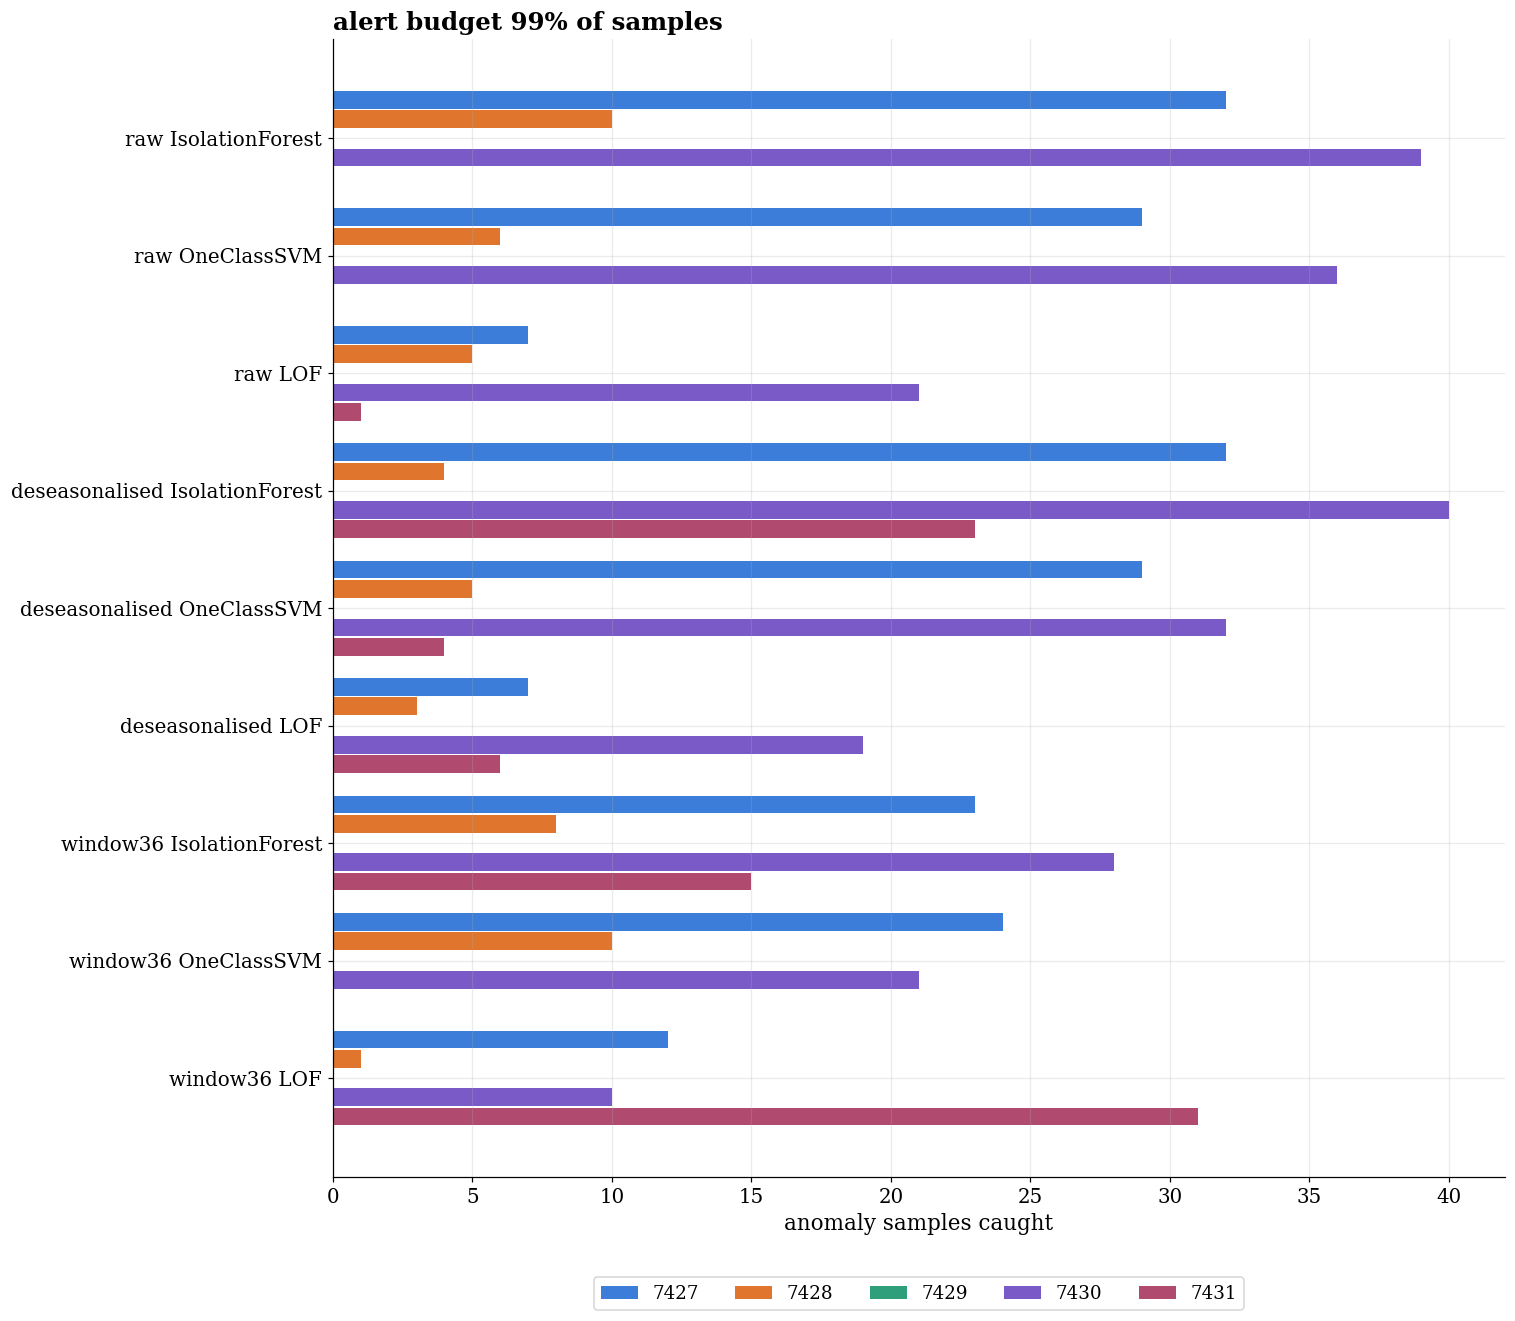

,port,method,alerts,caught,of,precision,column
0,7427,raw IsolationForest,87,32,62,0.368,traffic_bps
1,7427,raw OneClassSVM,87,29,62,0.333,traffic_bps
2,7427,raw LOF,87,7,62,0.080,traffic_bps
3,7427,deseasonalised IsolationForest,85,32,62,0.376,traffic_bps
4,7427,deseasonalised OneClassSVM,87,29,62,0.333,traffic_bps
5,7427,deseasonalised LOF,87,7,62,0.080,traffic_bps
6,7427,window36 IsolationForest,87,23,62,0.264,traffic_bps
7,7427,window36 OneClassSVM,87,24,62,0.276,traffic_bps
8,7427,window36 LOF,87,12,62,0.138,traffic_bps
9,7428,raw IsolationForest,86,10,50,0.116,traffic_bps


In [15]:
summary = (pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])
           .pivot(index="method", columns="port", values="caught").fillna(0).astype(int))
order = [f"{p} {m}" for p in ("raw", "deseasonalised", f"window{N_INPUT}")
         for m in ("IsolationForest", "OneClassSVM", "LOF")]
summary = summary.reindex([m for m in order if m in summary.index])

# One sub-bar per port, so the figure has to grow with the port count, not just the method
# count: five ports at a fixed row height collapse into one smear. bar_h keeps every group at a
# constant fraction of its row regardless of how many ports are configured.
n_ports = len(summary.columns)
bar_h = 0.82 / n_ports
w, h = plt.rcParams["figure.figsize"]
fig, ax = plt.subplots(figsize=(w, (0.16 * n_ports + 0.35) * len(summary) + 1.8))
y = np.arange(len(summary))
for k, port in enumerate(summary.columns):
    ax.barh(y + (k - (n_ports - 1) / 2) * bar_h, summary[port], height=bar_h * 0.92,
            color=PORT_C[k % len(PORT_C)], label=port)
ax.set_yticks(y, summary.index)
ax.invert_yaxis()
ax.set(xlabel="anomaly samples caught", title=f"alert budget {BUDGET:.0%} of samples")
ax.legend(ncol=n_ports, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])


No method wins everywhere; read the table below by situation, not by ranking.

### Which to reach for first

| situation | first choice |
|---|---|
| a hard limit exists | a rule: safety ceiling, SLO, error budget |
| one signal, clear pattern | a statistical baseline; check the cycle exists before removing it |
| several signals interacting | ML, but only after a fixed threshold and a rolling z-score |

These layer rather than compete — a fixed threshold under a statistical baseline under a model is
a normal production stack, not indecision.

In [16]:
resid_col = f"resid_{COLUMNS[0]}"
S_cusum_all = pd.Series(np.nan, index=df.index)
ew_all = pd.Series(np.nan, index=df.index)
tw_all = pd.Series(np.nan, index=df.index)
resid_lo, resid_hi = pd.Series(np.nan, index=df.index), pd.Series(np.nan, index=df.index)
acc = {name: pd.Series(False, index=df.index)
      for name in ("CUSUM k=1.5 h=5.0", "EWMA lam=0.2 over 4", "two-window over q99")}
for p in PORTS:
    gi = df.index[df["port_id"] == p]
    resid = df.loc[gi, resid_col].to_numpy()
    k = int(TRAIN_FRAC * len(resid))
    train = resid[:k]
    z = (resid - train.mean()) / train.std()
    S, alarm = cusum_score(z=z, k=1.5, h=5.0)
    ew = ewma_score(z=z, lam=0.2, L=1.0)
    tw = two_window(x=df.loc[gi, COLUMNS[0]], w=PERIOD, online=True)
    S_cusum_all.loc[gi], ew_all.loc[gi], tw_all.loc[gi] = S, ew.to_numpy(), tw.to_numpy()
    resid_lo.loc[gi] = train.mean() - 4 * train.std()
    resid_hi.loc[gi] = train.mean() + 4 * train.std()
    acc["CUSUM k=1.5 h=5.0"].loc[gi] = alarm
    acc["EWMA lam=0.2 over 4"].loc[gi] = np.abs(ew.to_numpy()) > 4
    acc["two-window over q99"].loc[gi] = (tw > tw.quantile(0.99)).fillna(False).to_numpy()

report(alerts=acc, data=df, ports=PORTS, events="all")

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,CUSUM k=1.5 h=5.0,160,0.475,6/18,2.5,2.80
1,EWMA lam=0.2 over 4,3685,0.033,8/18,0.0,118.85
2,two-window over q99,415,0.000,0/18,NaN,13.83


### What the three statistics look like together

The residual with the ±4σ band the underlying z is cut at, then all three statistics built on
it, same budget, side by side. All 5 ports.

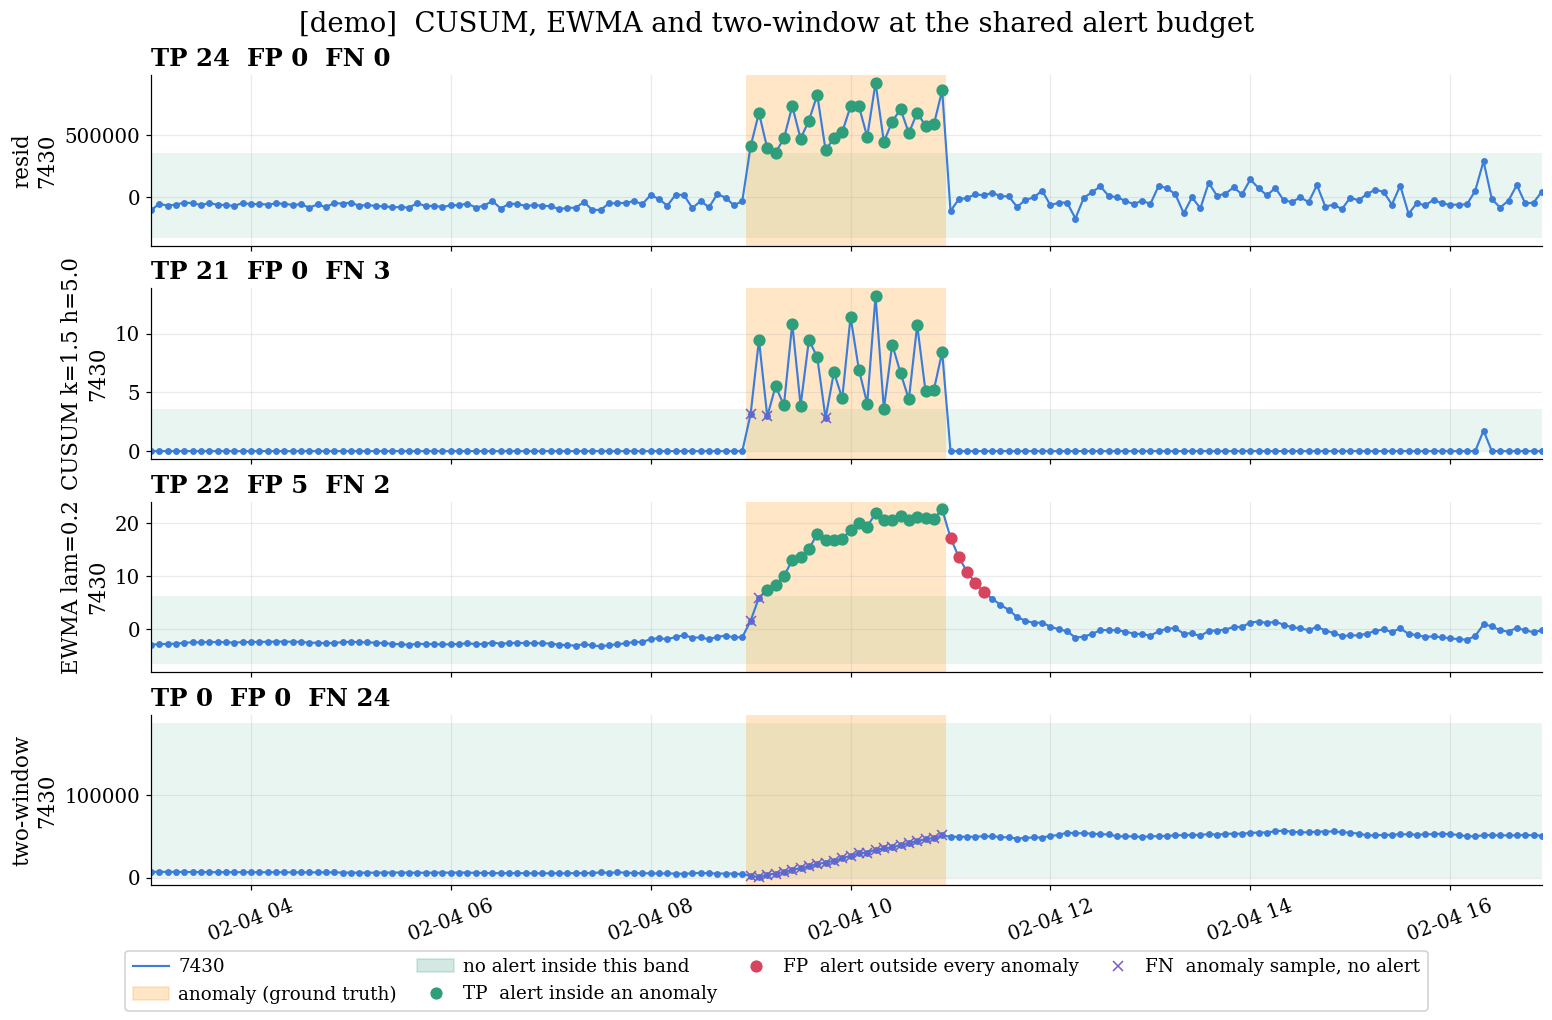

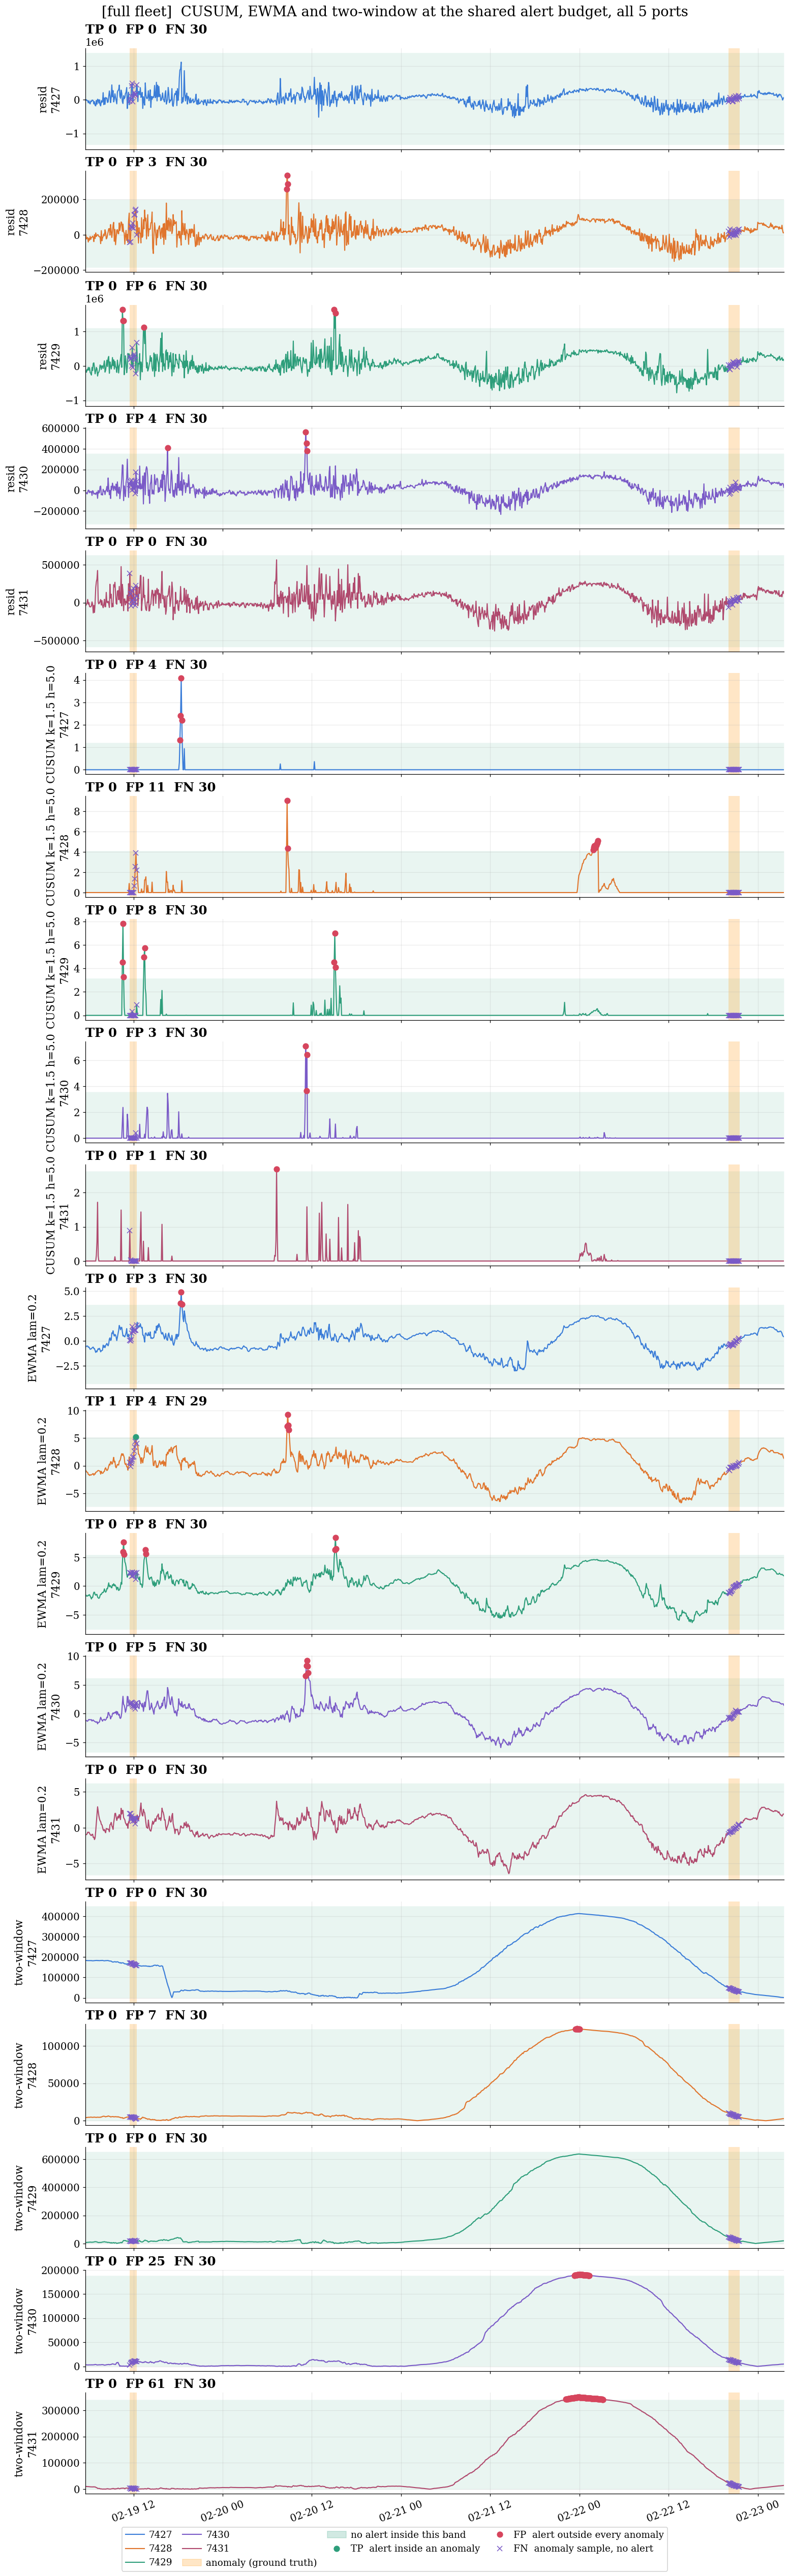

In [17]:
panel = df.assign(resid=df[resid_col], **{"CUSUM k=1.5 h=5.0": S_cusum_all,
                                          "EWMA lam=0.2": ew_all, "two-window": tw_all})
score_cols = ["CUSUM k=1.5 h=5.0", "EWMA lam=0.2", "two-window"]
thr = {c: panel[c].groupby(df["port_id"]).transform(lambda s: s.quantile(BUDGET))
      for c in score_cols}

alerts = {c: (panel[c] > thr[c]).fillna(False) for c in score_cols}
alerts["resid"] = ((panel["resid"] < resid_lo) | (panel["resid"] > resid_hi)).fillna(False)
bands = {c: (panel[c].groupby(df["port_id"]).transform("min"), thr[c]) for c in score_cols}
bands["resid"] = (resid_lo, resid_hi)

plot_signals(half=HALF, data=panel, columns=["resid"] + score_cols,
            ports=[CUSUM_EWMA_DEMO["port"]], events=[CUSUM_EWMA_DEMO["event"]],
            alerts=alerts, bands=bands, outcomes=True, by_port=True,
            zoom_anomaly=True, zoom_signal=False,
            title="[demo]  CUSUM, EWMA and two-window at the shared alert budget")
plot_signals(half=HALF, data=panel, columns=["resid"] + score_cols, ports=PORTS,
            events=ZOOM_EVENTS, alerts=alerts, bands=bands, outcomes=True, by_port=True,
            zoom_anomaly=True, zoom_signal=False,
            title="[full fleet]  CUSUM, EWMA and two-window at the shared alert budget, all 5 ports")

Two structural notes worth more than the numbers.

- **CUSUM must run with no confirmation layer.**
  - It resets to zero the moment it signals.
  - Its statistic is above the limit for exactly one sample by construction.
  - Requiring two in a row charges it twice for a property it has, and silences it.
- **The general rule:** a confirmation layer gives a *memoryless* score persistence, so it is
  redundant on any statistic that carries state.
- **EWMA is late in both directions.**
  - It peaks after the raw score and decays more slowly.
  - It buys smoothness with delay at the start and a tail of alerts after the anomaly is over.

## Step 8 — Composing many features, and the failure hiding inside it

- **Scoring one column asks "is this feature unusual". Operations wants "is this port unusual"**
  — a composition question.
- **Cheapest composition: max absolute z across features.** Max, not mean — a mean dilutes (one
  feature screaming, six quiet, averages down to mild), while max lets any single feature clear
  the cutoff alone. What max discards is agreement: it can't tell one feature at 12 from six at
  12.
- **The interesting part:** what happens when the six sparse features join in.

In [18]:
def robust_z_matrix(data=df, cols=None, ports=None, window=None, cap=50.0, floor_frac=0.05,
                    return_bands=False):
    """Absolute robust z for every column, per port, capped. Same length as data.

    The cap and the floor are numerical guards: without the floor a quiet stretch drives the MAD
    toward zero and any deviation scores in the thousands. Both are named here rather than buried,
    because the next cell is about what they do to the score's own distribution.

    return_bands=True also returns {col: (centre, scale)}, the rolling median and MAD each
    column's z was actually divided by. Composing several columns into one score discards the
    band — a max has no single signal left to draw one on — but any one column going in still
    has one, and that pair is what draws it.
    """
    cols = SCORABLE if cols is None else cols
    ports = PORTS if ports is None else ports
    window = WINDOW if window is None else window
    mp = max(3, window // 3)
    out, bands = {}, {}
    for col in cols:
        z = pd.Series(np.nan, index=data.index, dtype=float)
        centre = pd.Series(np.nan, index=data.index, dtype=float)
        scale = pd.Series(np.nan, index=data.index, dtype=float)
        for pid in ports:
            gi = data.index[data["port_id"] == pid]
            prev = data.loc[gi, col].shift(1)
            c = prev.rolling(window, min_periods=mp).median()
            sc = (prev - c).abs().rolling(window, min_periods=mp).median() * 1.4826
            whole = data.loc[gi, col].to_numpy(dtype=float)
            fl = max(floor_frac * 1.4826 * np.median(np.abs(whole - np.median(whole))), 1e-12)
            sc = sc.fillna(fl).clip(lower=fl)
            z.loc[gi] = ((data.loc[gi, col] - c) / sc).clip(-cap, cap)
            centre.loc[gi], scale.loc[gi] = c, sc
        out[col] = z.abs()
        bands[col] = (centre, scale)
    scores = pd.DataFrame(out, index=data.index)
    return (scores, bands) if return_bands else scores


CAP = 50.0            # the score cap, and the whole subject of this step
WINDOW = 12           # rolling window in samples, one hour. Lab 01 Step 9 is why
z_scorable = robust_z_matrix(data=df, cols=SCORABLE, ports=PORTS, window=WINDOW,
                             cap=CAP, floor_frac=0.05)
z_all = robust_z_matrix(data=df, cols=FEATURES, ports=PORTS, window=WINDOW,
                        cap=CAP, floor_frac=0.05)
score_scorable = z_scorable.max(axis=1)
score_all = z_all.max(axis=1)

for name, sc in [(f"max abs z over {len(SCORABLE)} scorable", score_scorable),
                 (f"max abs z over all {len(FEATURES)}", score_all)]:
    at_cap = float((sc >= CAP - 1e-9).mean())
    print(f"{name:32} at the cap {at_cap:7.2%} | q0.99 {np.nanquantile(sc.dropna(), 0.99):8.3f}"
          f" | q0.995 {np.nanquantile(sc.dropna(), 0.995):8.3f}")

max abs z over 7 scorable        at the cap   0.37% | q0.99    7.668 | q0.995   10.943
max abs z over all 13            at the cap  11.76% | q0.99   50.000 | q0.995   50.000


#### Your call — the composition rule

**This one the notebook does not compute for you.** `max(axis=1)` is what `score_scorable` and
`score_all` above actually use, argued for in this step's opening rather than measured — no cell
here runs the alternative and shows you the number.

- **Max ignores agreement.** One feature at 12 and six quiet looks identical to six features at
  12 together — the composed score cannot tell a single noisy sensor from a coordinated event.
- **Mean dilutes.** The same one screaming feature against several quiet ones averages toward
  mild, which is the failure Step 8's opening warned about and the reason `max` was chosen over
  it.
- **A vote (`(z > 4).sum(axis=1)`) needs a quorum you choose,** trading the max's single-feature
  sensitivity for a threshold on how many features must agree — a third free parameter, not a
  free lunch.

**Do it now.** Swap `max(axis=1)` for `mean(axis=1)` in the cell above, then for
`(z_scorable > 4).sum(axis=1)`. Re-run this step and the comparison-by-port above for all three, each cut
at `q = 0.995`. Which would you actually ship, and can you defend the choice to someone who was
not in the room when you made it?

### The composed score

One feature's band, then `score_scorable`: the max across all seven, alerting at the shared
budget. All 5 ports.

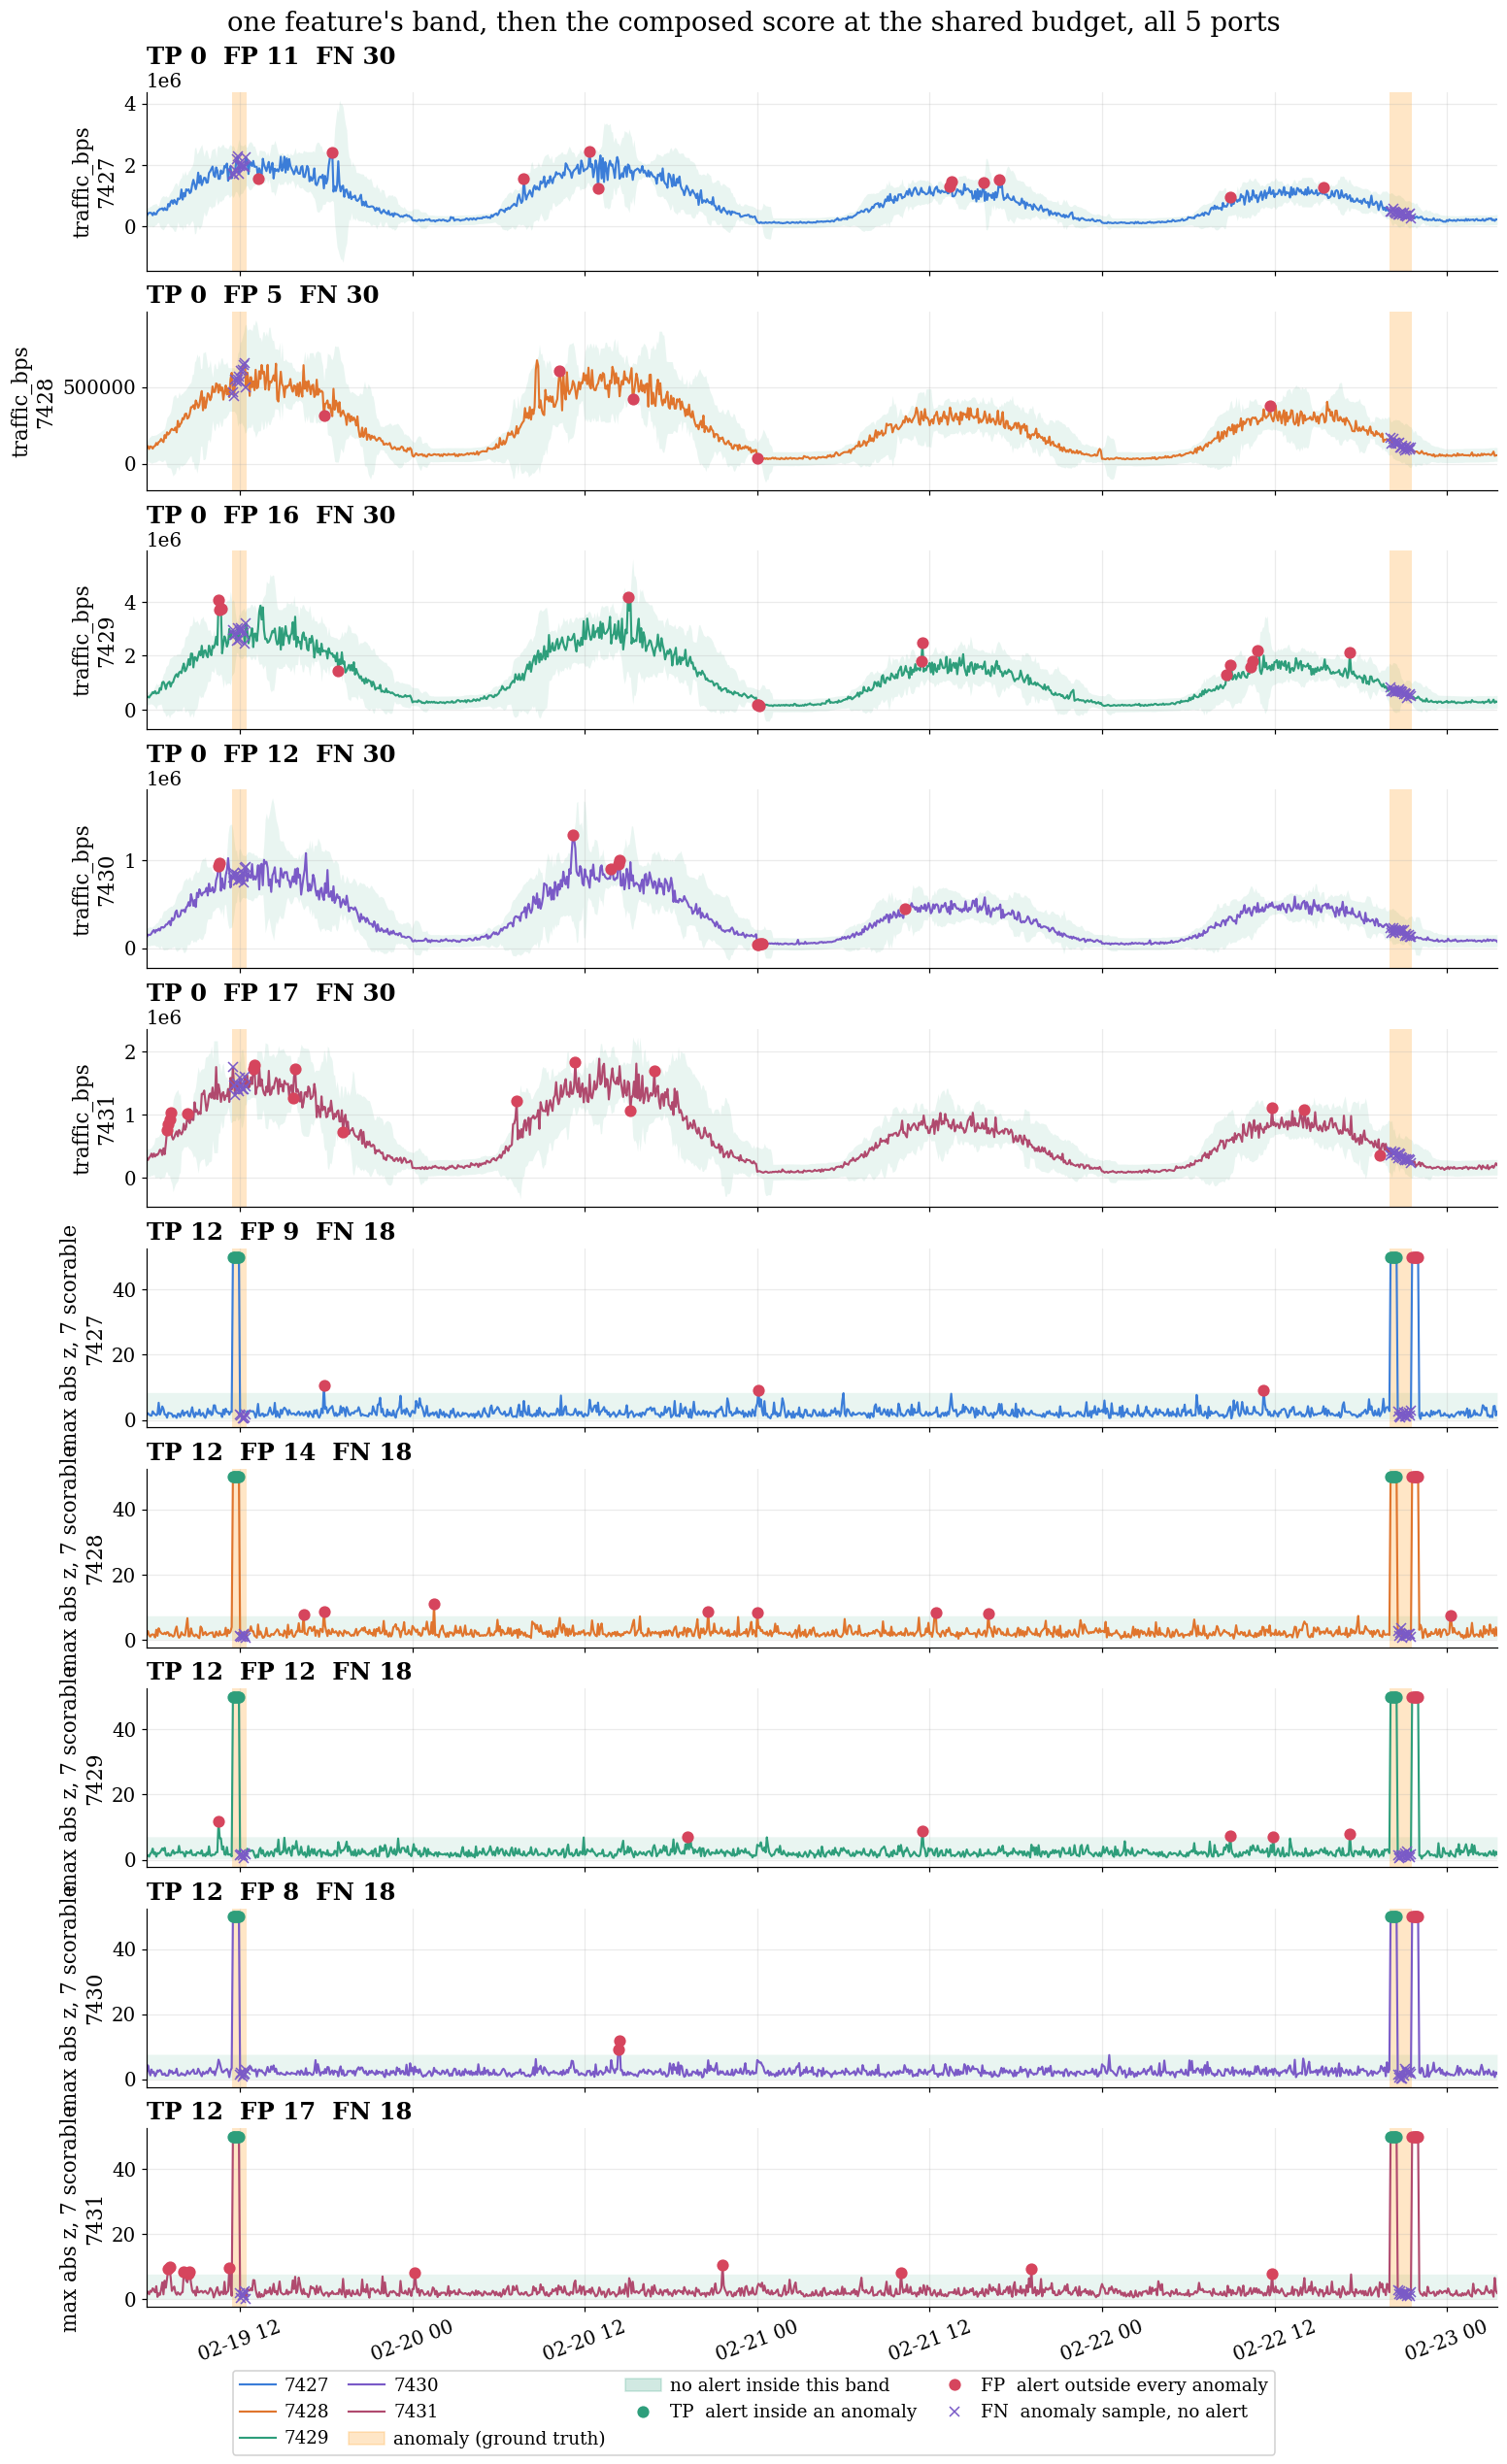

In [19]:
demo_col = COLUMNS[0]
_, demo_bands = robust_z_matrix(data=df, cols=[demo_col], ports=PORTS, window=WINDOW,
                                cap=CAP, floor_frac=0.05, return_bands=True)
centre, scale = demo_bands[demo_col]
score_col = f"max abs z, {len(SCORABLE)} scorable"

panel = df.assign(**{score_col: score_scorable})
thr = panel[score_col].groupby(df["port_id"]).transform(lambda s: s.quantile(BUDGET))
lo, hi = centre - 4 * scale, centre + 4 * scale

alerts = {demo_col: ((df[demo_col] < lo) | (df[demo_col] > hi)).fillna(False),
         score_col: (panel[score_col] > thr).fillna(False)}
bands = {demo_col: (lo, hi),
        score_col: (panel[score_col].groupby(df["port_id"]).transform("min"), thr)}

plot_signals(half=HALF, data=panel, columns=[demo_col, score_col], ports=PORTS,
            events=ZOOM_EVENTS, alerts=alerts, bands=bands, outcomes=True, by_port=True,
            zoom_anomaly=True, zoom_signal=False,
            title="one feature's band, then the composed score at the shared budget, all 5 ports")

Read the two `q0.995` numbers.

- **Seven scorable:** 0.37% at the cap, 99.5th percentile **10.9** — an ordinary number, a
  quantile still means something.
- **All thirteen:** 11.8% sit at the cap, so both the 99th and 99.5th percentile land *on* it.
  The score still works as a rule (a cutoff of 4 still separates) but stops working as a
  ranking — the foundation under every quantile, budget and precision-recall curve here.
- **A safety guard changed the score's statistics.** The cap belongs in a spec the next stage
  can read, not buried in a helper function.

#### Your call — `CAP`

**The decision:** where a numerical safety guard turns into a silent statistical failure.

- **The cap stops a quiet stretch from dividing by a near-zero scale.** Real protection, still
  needed — but a cap wide enough never to bind removes it, and a cap tight enough to matter
  removes the ranking once enough features share it. Composing more features makes the second
  failure more likely, not less.
- **Nothing here raises an error.** The score keeps producing numbers, a threshold keeps
  returning a boolean, and a quantile-based budget silently stops meaning what it claims to.

**Do it now.** Set `CAP = 1e6`, effectively removing it, and re-run this step. The `q = 0.995`
row on all thirteen columns should come back to life. What replaces the cap as the next failure,
and which of the two would you rather be paged about at 03:00?

In [20]:
tgt = df["event_label"].isin(ANOMALY_TYPES).to_numpy()
budget_rows = []
for name, sc in [("7 scorable", score_scorable), ("all 13", score_all)]:
    # A pooled quantile would let whichever port's score runs hottest eat the shared budget, so
    # each port gets its own 99.5th percentile even though the underlying z is already per-port.
    per_port_q = sc.groupby(df["port_id"]).transform(lambda s: s.quantile(0.995))
    for rule, thr, fired in [("abs z > 4", 4.0, sc > 4.0),
                             ("q = 0.995 per port", per_port_q, sc > per_port_q)]:
        m = fired.fillna(False).to_numpy()
        thr_shown = (round(float(thr), 3) if np.isscalar(thr) else
                    f"{thr.groupby(df['port_id']).first().min():.2f}"
                    f"–{thr.groupby(df['port_id']).first().max():.2f}")
        budget_rows.append({"columns": name, "rule": rule, "threshold": thr_shown,
                            "alerts": int(m.sum()), "hits_in_anomaly": int((m & tgt).sum()),
                            "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(budget_rows)


,columns,rule,threshold,alerts,hits_in_anomaly,alerts_per_day
0,7 scorable,abs z > 4,4.0,3683,107,119.20
1,7 scorable,q = 0.995 per port,9.19–15.04,220,100,4.00
2,all 13,abs z > 4,4.0,8169,131,267.93
3,all 13,q = 0.995 per port,50.00–50.00,0,0,0.00


- **The threshold rule matters more than the score.** `abs z > 4` on the seven scorable columns
  fires 3,683 times, 107 inside a real window — 2.9% precision, 119 alerts a day. `q = 0.995` per
  port, same score, no other change: 220 alerts, 100 real — **45.5% precision, 4 alerts a day.**
  Almost all the noise was the magic number, not the detector.
- **The `q = 0.995` row on all 13 columns is the one to sit with instead.** Threshold equals cap,
  comparison strict, detector emits nothing. No crash, no warning — a dashboard built on it looks
  healthy for as long as anyone watches.

### The ordering bug, which is the same class of failure

- **Score against the window, then append it — not the reverse.** Reversed, nothing errors, the
  chart still looks plausible, and recall dies in proportion to the anomaly's size: the anomaly
  is now inside its own baseline.
- **Measure it. Don't trust the comment.**

In [21]:
col, port = "traffic_bps", PORTS[1]
g = series_of(port=port, col=col, data=df)
v, w, mp = g["value"], WINDOW, max(3, WINDOW // 3)
tgt = g["target"].to_numpy()

rows_o = []
for kind in ("mean", "robust"):
    if kind == "mean":
        c_ok, s_ok = v.shift(1).rolling(w, min_periods=mp).mean(), v.shift(1).rolling(w, min_periods=mp).std()
        c_bug, s_bug = v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()
    else:
        c_ok = v.shift(1).rolling(w, min_periods=mp).median()
        s_ok = (v.shift(1) - c_ok).abs().rolling(w, min_periods=mp).median() * 1.4826
        c_bug = v.rolling(w, min_periods=mp).median()
        s_bug = (v - c_bug).abs().rolling(w, min_periods=mp).median() * 1.4826
    ok = ((v - c_ok).abs() / s_ok.clip(lower=1e-12)).clip(upper=CAP)
    bug = ((v - c_bug).abs() / s_bug.clip(lower=1e-12)).clip(upper=CAP)
    rows_o.append({"estimator": kind,
                   "correct peak": round(float(ok[tgt].max()), 2),
                   "bug peak": round(float(bug[tgt].max()), 2),
                   "correct samples > 4": int((ok[tgt] > 4).sum()),
                   "bug samples > 4": int((bug[tgt] > 4).sum()),
                   "of": int(tgt.sum())})
pd.DataFrame(rows_o)

,estimator,correct peak,bug peak,correct samples > 4,bug samples > 4,of
0,mean,5.12,2.68,1,0,50
1,robust,4.10,3.69,1,0,50


**The same one-line ordering bug costs the mean estimator half its signal, the robust one a
tenth.**

- **Mean:** peak 5.12 → 2.68, roughly halved. The one sample that cleared the `> 4` cutoff stops
  clearing it.
- **Robust:** peak 4.10 → 3.69, about a tenth — and still loses that same one sample, since 4.10
  was never far above the cutoff to begin with.
- **Why the gap:** mean has a breakdown point of zero, one contaminated sample moves it. Median
  needs over half the window; one sample in twelve isn't close.
- **Backwards from the usual pitch.** Robustness is sold against dirty data; here it also
  protected against a coding error, and nothing in a test suite or a chart would have told you
  which implementation was running. Nothing raised, nothing logged, output still plausible — a
  pipeline that fails loudly is a pipeline you can fix.

## Step 9 — Combining what already works

Step 7 closed on layering: a fixed threshold under a statistical baseline under a model, not a
horse race with one winner. Tested here, against all five ports and all eighteen events: does
combining detectors, or feeding a detector an engineered feature instead of a raw one, beat
every single method in this lab?

### What didn't help

- **IsolationForest on the real 7-column feature matrix**, not one raw column: ties the composed
  score (44.1% vs 45.5% precision) rather than beating it — a `max` over the same seven columns
  already does what the forest learns.
- **CUSUM or EWMA on the composed score itself**, as if it were a residual: fires on nothing —
  the composed score is already heavy-tailed even when quiet, leaving no stable baseline to
  depart from.
- **A 3-way vote and a rank-fused score** across composed/CUSUM/EWMA: both land within noise of
  the composed score alone (0 alerts, and 46.9% precision).

### What worked

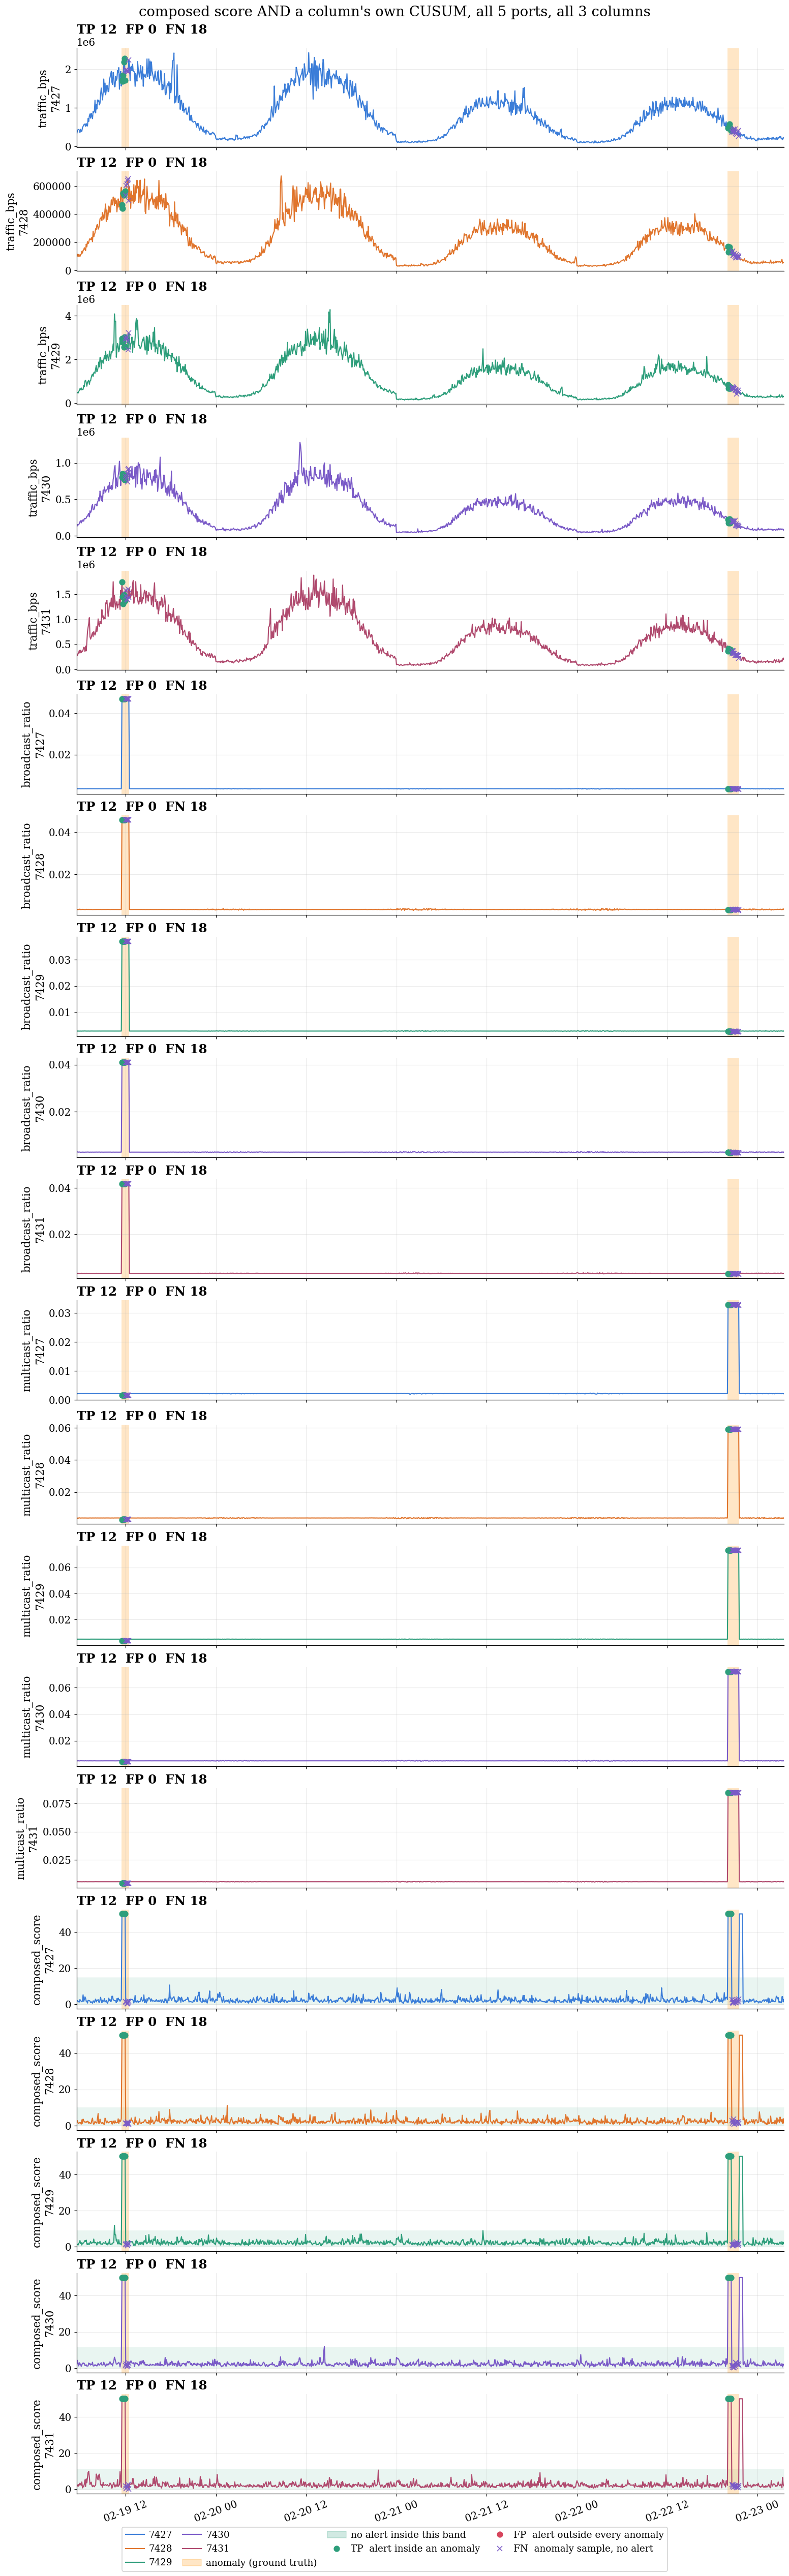

,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,composed alone,220,0.455,17/18,0.0,4.00
1,composed AND CUSUM (any column),92,0.891,16/18,0.0,0.33


,port,detector,alerts,precision,anomaly_recall,delay_min,alerts_per_day
0,port-id7427,composed alone,44,0.500,4/4,0.0,0.73
1,port-id7427,composed AND CUSUM,23,0.957,4/4,0.0,0.03
2,port-id7428,composed alone,44,0.545,4/4,0.0,0.67
3,port-id7428,composed AND CUSUM,14,0.929,3/4,0.0,0.03
4,port-id7429,composed alone,44,0.273,2/3,0.0,1.07
5,port-id7429,composed AND CUSUM,15,0.800,2/3,0.0,0.10
6,port-id7430,composed alone,44,0.545,4/4,0.0,0.67
7,port-id7430,composed AND CUSUM,22,0.955,4/4,0.0,0.03
8,port-id7431,composed alone,44,0.409,3/3,0.0,0.87
9,port-id7431,composed AND CUSUM,18,0.778,3/3,0.0,0.13


In [22]:
per_port_q995 = score_scorable.groupby(df["port_id"]).transform(lambda s: s.quantile(0.995))
composed_alert = score_scorable > per_port_q995                  # Step 8's own rule, unchanged
cusum_any_col = pd.concat([df[f"cusum_{c}"] > 5.0 for c in COLUMNS], axis=1).any(axis=1)
combined_alert = composed_alert & cusum_any_col                  # the only new line

# All 5 ports, all 3 taught columns plus the composed score itself, so the improvement is checked
# against the real signals rather than trusted from one derived line.
df["composed_score"] = score_scorable
plot_signals(half=HALF, data=df, columns=COLUMNS + ["composed_score"], ports=PORTS,
            events=ZOOM_EVENTS, alerts={c: combined_alert for c in COLUMNS + ["composed_score"]},
            bands={"composed_score": (0.0, per_port_q995)},
            outcomes=True, by_port=True, zoom_anomaly=True, zoom_signal=False,
            title="composed score AND a column's own CUSUM, all 5 ports, all 3 columns")

display(report(alerts={"composed alone": composed_alert,
                       "composed AND CUSUM (any column)": combined_alert},
               data=df, ports=PORTS, events="all"))

# Fleet precision is a mean, and a mean hides one port carrying the whole gain. Broken out per
# port to check that directly.
pd.concat([report(alerts={"composed alone": composed_alert,
                          "composed AND CUSUM": combined_alert},
                  data=df, ports=[pid], events="all").assign(port=pid)
          for pid in PORTS], ignore_index=True)[
    ["port", "detector", "alerts", "precision", "anomaly_recall", "delay_min", "alerts_per_day"]]

**Precision 45.5% → 89.1%, alerts 4.0/day → 0.33/day — on every one of the 5 ports**, from
requiring Step 7's composed score AND a column's own CUSUM to agree: one boolean `AND` on two
detectors already built, no new fitting. Per-port table above: minimum gain +37 points, none
moving backward.

- **The cost:** one additional missed window, `unknown_protocol_scan` on `port-id7428` — the
  composed score spikes on it, no column's CUSUM does. `link_quality_issue` on `port-id7429` was
  already missed by the composed score alone.
- **Adding EWMA to the same `AND`:** 91 alerts, 90.1% precision — inside rounding noise. Two
  agreeing detectors already capture the effect.
- **Corroboration, not fusion:** the composed score and CUSUM fail in different places — a
  static outlier test versus accumulated evidence. Averaging their ranks blends the failures
  back together; requiring both to fire keeps only where two different failure modes agree.

## Exercises

Five measurements, then four designs that need what you know about your own network.

### Measure it

1. **Window length.** `N_INPUT` to `12`, then `288`, re-run Step 7.
   - At `288` detection collapses — explain it from the definition of the window.
   - Check against Lab 01 Step 16a.
   - `N_INPUT` arrives through the spec: a permanent change belongs in Lab 01, a temporary one below
     Step 3.
2. **CUSUM slack.** `k` to `0.25`, then `3.0`. How does the alarm count move, and which value would
   you defend to an on-call team?
3. **EWMA memory.** `lam` to `0.05`, then `0.8`.
   - Watch alert count *and* delay to first alert.
   - Then remove the `/ limit` and re-run: which λ still fires, and does
     `implied_threshold_if_unscaled` explain which do not?
4. **The cap.** `CAP = 1e6`, effectively removing it.
   - The `q = 0.995` row on all 13 columns comes back to life.
   - What replaces the cap as the failure, and which would you rather debug at 03:00?
5. **Composition rule.** Swap `max(axis=1)` for `mean(axis=1)`, then `(z > 4).sum(axis=1)`.
   - Max ignores agreement, mean dilutes, voting needs a quorum you choose.
   - Score all three at `q = 0.995` and say which you would ship.

### Design it

6. **Which family fits your team?**
   - The real difference is maintenance, not accuracy.
   - A fixed rule needs a human to pick a line per metric, then holds forever.
   - A model needs someone to confirm the training period still represents normal.
   - Which cost can your team carry, and what would make the other affordable?
7. **Explain a model score to your on-call.**
   - A z of 4 is four standard deviations. An isolation score of 0.6384 is indefensible in a review.
   - Draft the two sentences for the alert payload, then decide whether they justify waking someone.
   - If not, that argues for a statistical detector *in front of* the model.
8. **Design the seasonal bucket your traffic has.**
   - Lab 01's `decompose` assumes one daily period.
   - Write the key one service you support would need, and how much history each bucket requires.
9. **Pick the swap that would break production.**
   - Everything downstream of the score is detector-agnostic except the threshold.
   - Write what happens if someone swaps a scoring function and leaves the constant.
   - Then write the check that would have caught it. It is easier to write than the incident review.

In [23]:
# YOUR CODE HERE

## Summary

- **A contract beats a convention.** This lab recomputes no feature and refits no scaler. It asserts
  the frame matches the spec and stops if it does not.
- **The framing decides more than the model.** Three detectors sit within 8% of each other overall,
  while one framing choice swings recall by 4.6× on a single column.
- **A transform that assumes a cycle, used where there is none, destroys signal.** Deseasonalising
  `multicast_ratio` takes 705 caught samples down to 154. Lab 01 measured the missing cycle before a
  model ran; running the model anyway would have looked like a modelling failure.
- **State buys persistence and costs latency.** CUSUM needs no confirmation layer; EWMA is late in
  both directions; both need their scale stated or the threshold silently moves.
- **A guard rail changes the statistics it guards.** The score cap turns a working ranking into a
  constant, and every quantile built on it dies quietly.
- **A change point is an investigation, not a verdict.** The largest level changes this month are
  weekends.
- **Two detectors agreeing beats one detector tuned harder.** Requiring the composed score and a
  column's own CUSUM to fire together took precision from 45.5% to 89.1% and alerts a day from
  4.0 to 0.33, for one additional missed window. Averaging the same two scores into one ranked
  number did not — corroboration and fusion are not the same move, and only one of them worked
  here.

Both labs scored one signal at a time. The anomalies that stayed hardest — the ones needing a
**ratio** between two counters read together — are where multivariate detection starts.